# AI Tối Ưu Lịch Trình MTA

Dữ liệu → forecast nhu cầu (MLP + HistGBM) → queue wait + vehicle-hours → Pareto knee → lịch GTFS.

| Thư mục | Nội dung |
|---------|----------|
| `../datasets/` | Ridership, thời tiết, GTFS |
| `outputs/default/` | Schedules, metrics, figures |
| `outputs/default/ui_export/` | Artifacts cho API (§9) |

**Kịch bản:** `weekday_peak`, `weekend`, `rainy_day`.


## 1. Setup & imports

Cấu hình đường dẫn, hyperparameter và import thư viện.


In [1]:
import os
import json
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import sys
import importlib

_cwd = Path(".").resolve()
if (_cwd / "lib" / "single_route_pipeline.py").is_file():
    NOTEBOOK_DIR = _cwd
elif (_cwd / "notebooks" / "lib" / "single_route_pipeline.py").is_file():
    NOTEBOOK_DIR = _cwd / "notebooks"
else:
    raise ImportError(f"Cannot locate notebooks/lib from cwd={_cwd}")

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import lib.single_route_pipeline as srp
importlib.reload(srp)

REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = REPO_ROOT / "datasets"
SCHEDULE_DIR = REPO_ROOT / "datasets" / "schedule_current"

DEMAND_MODEL_TYPE = "blend"
USE_HISTGBM_BLEND = True
CV_USE_BLEND = True
TUNE_RESID_CLIP_ON_VAL = True
HISTGBM_BLEND_WEIGHT = None

OUT_DIR = Path("outputs/default")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_FILE = DATA_DIR / "train_manifest.json"
if MANIFEST_FILE.exists():
    with open(MANIFEST_FILE, encoding="utf-8") as f:
        train_manifest = json.load(f)
else:
    train_manifest = {}

_DEFAULT_PATHS = {
    "ridership": "ridership.csv",
    "routes_by_station_complex": "routes_by_station_complex.csv",
    "routes": "routes.csv",
    "factors_hourly": "factors_hourly.csv",
    "headway_by_route_hour": "headway_by_route_hour.csv",
    "factors_daily": "factors_daily.csv",
}

def data_path(key: str) -> Path:
    """Resolve path trong DATA_DIR (ridership bundle); không dùng cho GTFS."""
    paths_cfg = train_manifest.get("paths", {}) or {}
    name = paths_cfg.get(key, _DEFAULT_PATHS.get(key, key))
    return DATA_DIR / name

RIDERSHIP_FILE = data_path("ridership")
ROUTES_BY_COMPLEX_FILE = data_path("routes_by_station_complex")
FACTORS_HOURLY_FILE = data_path("factors_hourly")
FACTORS_MODE = "hourly"
FACTORS_JOIN_KEYS = ["date", "hour"]

_scope = train_manifest.get("scope", {})
OPT_HOURS_FALLBACK = _scope.get("hours", list(range(24)))
OPT_HOURS = list(OPT_HOURS_FALLBACK)
USE_GTFS_OPERATING_HOURS = True
MIN_GTFS_TRIPS_PER_HOUR = 1

OPT_ROUTE_MODE = _scope.get("route_mode", "headway")
DIRECTIONS = _scope.get("directions", [0, 1])
MIN_ROUTE_DEMAND_ROWS = 50
ROUTE_ALIASES = train_manifest.get("route_aliases", {"SIR": "SI"})
HEADWAY_SERVICE = "Weekday"

COVERAGE_THR = 0.7
CHUNK_ROWS = 1_000_000
NN_EPOCHS_MAIN = 200
NN_EPOCHS_CV = 80
CV_SPLITS = 8
CV_SEASON_YEARS = 2
HOLDOUT_TEST_SEASON = "autumn"
HOLDOUT_TEST_YEAR = 2025
HOLDOUT_VAL_SEASON = "summer"
HOLDOUT_VAL_YEAR = 2025

USE_ROUTE_EMBEDDING = True
USE_LAG_FEATURES = True
LAG_FEATURE_COLS = ["log_lag_24h", "log_lag_168h", "log_rolling_7d"]
RESID_CLIP = (-0.4, 0.4)
RESID_CLIP_CANDIDATES = [0.35, 0.45, 0.55]
CV_BLEND_TUNE_FRAC = 0.15
PEAK_SAMPLE_WEIGHT = 2.0
NN_HIDDEN = (64, 32)
NN_DROPOUT = 0.25
USE_BATCH_NORM = True
# Pareto λ scan default (§5b overwrites from median knee); §6 uses USE_PER_ROUTE_LAMBDA
LAMBDA_TRADEOFF = 655.0
USE_PER_ROUTE_LAMBDA = True
LAMBDA_COST = LAMBDA_TRADEOFF  # alias for legacy cells
COST_PER_VEHICLE_HOUR = 150.0  # optional $ display: fleet_cost = VH × rate
LAMBDA_GRID = [100, 150, 200, 400, 600, 1000]

RAINY_HOUR_BOOST: dict[int, float] = {
    17: 1.18, 18: 1.22, 19: 1.18, 8: 1.10, 9: 1.10,
}

TRIPS_MIN_FACTOR = 0.5
TRIPS_OVERNIGHT_MIN_FACTOR = 0.32
TRIPS_PEAK_MAX_FACTOR = 1.40   # peak: tighter max (upgrade_model.md §7)
TRIPS_OFFPEAK_MAX_FACTOR = 1.15
TRIPS_OVERNIGHT_MAX_FACTOR = 1.05
TRIPS_MAX_DELTA = 3
# Headway → trips bounds (single source of truth, merged with dynamic baseline bounds in §5)
MIN_HEADWAY_MIN = 3.0    # peak subway ~2–3 min (NYC)
MAX_HEADWAY_MIN = 20.0   # off-peak upper headway
OVERNIGHT_MAX_HEADWAY_MIN = 30.0
TURNAROUND_BUFFER_MIN = 5.0  # terminal dwell each end (MTA ops ~3–5 min; no GTFS field)
MAX_OVERFLOW_PCT = 1.0   # capacity floor target
SMOOTHNESS_MAX_DELTA = TRIPS_MAX_DELTA
LAMBDA_AUTO_CALIBRATE = True
USE_ANALYTICAL_OPT = True   # full 29 routes: analytical
TARGET_MAX_BIND_FRACTION = 0.45
TARGET_PEAK_BIND_FRACTION = 0.35  # λ_calibrate chỉ kiểm peak @ TRIPS_MAX
RAINY_PEAK_TRIPS_MIN_FACTOR = 0.62
RAINY_OFFPEAK_MAX_FACTOR = 1.42
SPLIT_DEMAND_BY_DIRECTION = True

# OPT_TARGET / LAMBDA_OPT / USE_PARETO_KNEE_LAMBDA / LAMBDA_CANDIDATES — replaced by lambda_knee_per_route (§5b_per_route)

# Quantile GBM cho scenario rủi ro (conservative demand)
RISK_SCENARIOS = ("rainy_day",)
RISK_DEMAND_QUANTILE = 0.75

PARETO_N_POINTS = 20

PEAK_HOURS = (7, 8, 9, 17, 18, 19)

HOURLY_FACTOR_COLS = [
    "temperature_c", "apparent_temperature_c",
    "precipitation_mm", "rain_mm", "snowfall_cm",
    "windspeed_kmh", "windgusts_kmh",
    "is_rain", "is_snow", "is_severe_wind",
    "is_major_event_window",
]


print("TensorFlow:", tf.__version__)
print(f"Demand model: {DEMAND_MODEL_TYPE} (MLP + HistGBM)")
print("Data dir:", DATA_DIR.resolve())
print("Output dir:", OUT_DIR.resolve())
for label, p in [
    ("ridership", RIDERSHIP_FILE),
    ("routes_by_station_complex", ROUTES_BY_COMPLEX_FILE),
    ("factors_hourly", FACTORS_HOURLY_FILE),
    ("schedule", SCHEDULE_DIR),
]:
    print(f"  {label}: {'OK' if p.exists() else 'MISSING'} — {p.name if p.is_file() else p}")



TensorFlow: 2.20.0
Demand model: blend (MLP + HistGBM)
Data dir: D:\tranport-public\datasets
Output dir: D:\tranport-public\notebooks\outputs\default
  ridership: OK — ridership.csv
  routes_by_station_complex: OK — routes_by_station_complex.csv
  factors_hourly: OK — factors_hourly.csv
  schedule: OK — D:\tranport-public\datasets\schedule_current


## 2. Load & hợp nhất dữ liệu

- **Ridership** — nhu cầu theo ga × giờ.
- **GTFS** — headway baseline từ `stop_times`.
- **Thời tiết** — `factors_hourly.csv` join `(date, hour)`.


In [2]:
routes_complex = pd.read_csv(ROUTES_BY_COMPLEX_FILE)
routes_complex["station_complex_id"] = routes_complex["station_complex_id"].astype(str)

route_col = "gtfs_route_ids" if "gtfs_route_ids" in routes_complex.columns else "route_ids_gtfs"
station_to_routes = (
    routes_complex.assign(route=routes_complex[route_col].astype(str).str.split())
    .explode("route")
    .dropna(subset=["route"])
)
station_to_routes = station_to_routes[station_to_routes["route"] != ""]
station_to_routes = station_to_routes[["station_complex_id", "route"]].drop_duplicates()
station_to_routes["route"] = station_to_routes["route"].replace(ROUTE_ALIASES)

print("Tổng map station→route:", len(station_to_routes))
print("Số ga có map:", station_to_routes["station_complex_id"].nunique())
print("Số tuyến xuất hiện:", station_to_routes["route"].nunique())


Tổng map station→route: 767
Số ga có map: 445
Số tuyến xuất hiện: 26


In [3]:
usecols = ["transit_timestamp", "transit_mode", "station_complex_id", "ridership"]
valid_stations = set(station_to_routes["station_complex_id"].unique())

agg_parts = []
for chunk in pd.read_csv(
    RIDERSHIP_FILE,
    usecols=usecols,
    chunksize=CHUNK_ROWS,
    parse_dates=["transit_timestamp"],
    dtype={"station_complex_id": str},
):
    chunk = chunk[chunk["transit_mode"] == "subway"]
    chunk = chunk[chunk["station_complex_id"].isin(valid_stations)]
    if chunk.empty:
        continue
    chunk["date"] = chunk["transit_timestamp"].dt.date
    chunk["hour"] = chunk["transit_timestamp"].dt.hour
    grp = (
        chunk.groupby(["station_complex_id", "date", "hour"], as_index=False)["ridership"]
        .sum()
    )
    agg_parts.append(grp)

ridership_station = pd.concat(agg_parts, ignore_index=True)
print(f"Aggregated (station,date,hour) rows: {len(ridership_station):,}")
print("Date range:", ridership_station["date"].min(), "→", ridership_station["date"].max())


Aggregated (station,date,hour) rows: 7,294,700
Date range: 2023-12-01 → 2025-11-30


In [4]:
ridership_station = (
    ridership_station.groupby(["station_complex_id", "date", "hour"], as_index=False)["ridership"]
    .sum()
)

# Phân bổ ridership ga→tuyến theo trọng số chuyến GTFS (chỉ route hoạt động trong giờ)
headway = srp.build_headway_from_gtfs(SCHEDULE_DIR, service_id=HEADWAY_SERVICE)
headway["route_id"] = headway["route_id"].astype(str)
route_hour_trips = srp.build_route_hour_trip_counts(
    headway, min_trips=MIN_GTFS_TRIPS_PER_HOUR
)
station_route_weights = srp.build_station_route_hour_weights(
    station_to_routes,
    route_hour_trips,
    min_trips=MIN_GTFS_TRIPS_PER_HOUR,
    route_aliases=ROUTE_ALIASES,
)
ridership_route = srp.aggregate_ridership_to_routes(
    ridership_station,
    station_route_weights,
    coverage_thr=COVERAGE_THR,
)

print(f"Total (route,date,hour) records (coverage≥{COVERAGE_THR}): {len(ridership_route):,}")
print(f"Coverage stats: mean={ridership_route['coverage'].mean():.2f}, "
      f"min={ridership_route['coverage'].min():.2f}, "
      f"max={ridership_route['coverage'].max():.2f}")
print(f"Unique dates: {ridership_route['date'].nunique()}")
headway.to_csv(OUT_DIR / "headway_by_route_hour_derived.csv", index=False)

Total (route,date,hour) records (coverage≥0.7): 399,840
Coverage stats: mean=0.99, min=0.70, max=1.00
Unique dates: 731


In [5]:
def load_factors_hourly(path: Path) -> pd.DataFrame:
    """Load hourly weather/calendar; one row per (date, hour)."""
    fh = pd.read_csv(path, parse_dates=["timestamp", "date"])
    if "hour" not in fh.columns:
        fh["hour"] = fh["timestamp"].dt.hour
    keep = [
        "date", "hour", "day_of_week", "is_weekend", "is_us_holiday", "month",
        "temperature_c", "apparent_temperature_c",
        "precipitation_mm", "rain_mm", "snowfall_cm",
        "windspeed_kmh", "windgusts_kmh",
        "is_rain", "is_snow", "is_severe_wind",
        "is_major_event_window",
    ]
    keep = [c for c in keep if c in fh.columns]
    fh = fh[keep].drop_duplicates(subset=["date", "hour"]).copy()
    fh["date"] = pd.to_datetime(fh["date"]).dt.normalize()
    fh["hour"] = fh["hour"].astype(int)
    return fh


factors = load_factors_hourly(FACTORS_HOURLY_FILE)
print("Factors: hourly", factors.shape, "| cols:", len(factors.columns))


Factors: hourly (17544, 17) | cols: 17


In [6]:
ridership_route["date"] = pd.to_datetime(ridership_route["date"]).dt.normalize()
ridership_route["hour"] = ridership_route["hour"].astype(int)


ridership_all = ridership_route.merge(factors, on=FACTORS_JOIN_KEYS, how="left")
if "day_of_week" in ridership_all.columns:
    ridership_all["day_of_week"] = ridership_all["day_of_week"].fillna(
        ridership_all["date"].dt.dayofweek
    )
else:
    ridership_all["day_of_week"] = ridership_all["date"].dt.dayofweek
if "is_weekend" in ridership_all.columns:
    ridership_all["is_weekend"] = ridership_all["is_weekend"].fillna(
        (ridership_all["date"].dt.dayofweek >= 5).astype(int)
    )
else:
    ridership_all["is_weekend"] = (ridership_all["date"].dt.dayofweek >= 5).astype(int)
miss = ridership_all["is_rain"].isna().mean() if "is_rain" in ridership_all.columns else 1.0
print(f"Merge hourly on {FACTORS_JOIN_KEYS}: missing weather rows = {miss:.2%}")

flag_cols = [
    "is_us_holiday", "is_rain", "is_snow", "is_severe_wind",
    "is_major_event_window",
]
num_cols = [c for c in HOURLY_FACTOR_COLS if c not in flag_cols]

for c in num_cols:
    if c not in ridership_all.columns:
        ridership_all[c] = 0.0
    ridership_all[c] = ridership_all[c].fillna(ridership_all[c].median())
for c in flag_cols:
    if c not in ridership_all.columns:
        ridership_all[c] = 0
    ridership_all[c] = ridership_all[c].fillna(0).astype(int)

print("Merged ridership shape:", ridership_all.shape)
print("Hours:", sorted(ridership_all["hour"].unique()))


Merge hourly on ['date', 'hour']: missing weather rows = 0.00%
Merged ridership shape: (399840, 20)
Hours: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


## 3. EDA & chọn scope

Khám phá dữ liệu trước khi huấn luyện:

| Biểu đồ | Mục đích |
|---------|----------|
| `fig_eda_data_overview` | Khối lượng theo tháng, coverage, số tuyến scope, phân phối demand |
| `fig_eda_demand_patterns` | Top tuyến, profile giờ (weekday/weekend), heatmap ngày×giờ, mưa |
| `fig_eda_scope_headway` | Bản ghi training theo tuyến, headway GTFS median |
| `fig_eda_route_hour_heatmap` | Heatmap demand top 10 tuyến × giờ |

Sau EDA: chọn `OPT_ROUTES` và slot `(route × direction × hour)` theo GTFS.


In [7]:
HEADWAY_ROUTES = sorted(headway["route_id"].astype(str).unique())
route_row_counts = ridership_all.groupby("route_id").size()
RIDERSHIP_ROUTES = route_row_counts[route_row_counts >= MIN_ROUTE_DEMAND_ROWS].index.astype(str).tolist()

if OPT_ROUTE_MODE == "headway":
    OPT_ROUTES = HEADWAY_ROUTES
elif OPT_ROUTE_MODE == "intersection":
    OPT_ROUTES = sorted(set(HEADWAY_ROUTES) & set(RIDERSHIP_ROUTES))
else:
    OPT_ROUTES = RIDERSHIP_ROUTES

EXCLUDED_NO_RIDERSHIP = [r for r in OPT_ROUTES if r not in set(RIDERSHIP_ROUTES)]
OPT_ROUTES = [r for r in OPT_ROUTES if r in set(RIDERSHIP_ROUTES)]
if EXCLUDED_NO_RIDERSHIP:
    print(f"Loại {len(EXCLUDED_NO_RIDERSHIP)} tuyến không có ridership: {EXCLUDED_NO_RIDERSHIP}")

route_totals = (
    ridership_all.groupby("route_id")["demand"].mean().sort_values(ascending=False)
)
print("Top 12 tuyến theo demand TB/giờ:")
print(route_totals.head(12).round(0))
print()
print(f"OPT_ROUTES ({len(OPT_ROUTES)} tuyến, mode={OPT_ROUTE_MODE}):", OPT_ROUTES[:8], "...")

route_hours = {r: list(OPT_HOURS_FALLBACK) for r in OPT_ROUTES}
route_dir_hours: dict[tuple[str, int], list[int]] = {}
if USE_GTFS_OPERATING_HOURS:
    route_dir_hours = srp.derive_operating_hours_by_route_direction(
        headway, OPT_ROUTES, directions=DIRECTIONS, min_trips=MIN_GTFS_TRIPS_PER_HOUR
    )
    route_hours = srp.derive_operating_hours_by_route(
        headway, OPT_ROUTES, directions=DIRECTIONS, min_trips=MIN_GTFS_TRIPS_PER_HOUR
    )
    empty = [k for k, hs in route_dir_hours.items() if not hs]
    if empty:
        raise ValueError(f"Không có giờ GTFS cho: {empty[:8]}")
    OPT_HOURS = sorted({h for hs in route_dir_hours.values() for h in hs})
    print(f"GTFS operating hours (route×dir): {len(route_dir_hours)} keys, union {len(OPT_HOURS)} hours")
    lens = [len(hs) for hs in route_dir_hours.values()]
    print(f"  hours per route×dir: min={min(lens)}, max={max(lens)}")

OPT_SCOPE = [
    (r, d, h) for r in OPT_ROUTES for d in DIRECTIONS
    for h in (route_dir_hours.get((r, d)) or route_hours.get(r, OPT_HOURS_FALLBACK))
]
print(f"OPT_SCOPE slots (pre-filter ridership): {len(OPT_SCOPE)}")

df = ridership_all[ridership_all["route_id"].isin(OPT_ROUTES)].copy()
n_all = len(df)
if USE_GTFS_OPERATING_HOURS:
    df = df[df.apply(lambda row: row["hour"] in route_hours.get(row["route_id"], []), axis=1)].copy()
print()
print(f"Dataset NN: {len(df):,} bản ghi ({n_all:,} trước lọc giờ), "
      f"{df['date'].nunique()} ngày, routes={df['route_id'].nunique()}")
print(f"Demand range: {df['demand'].min():.0f} – {df['demand'].max():.0f}")
MISSING_RIDERSHIP_ROUTES = list(EXCLUDED_NO_RIDERSHIP)
print(f"Tuyến đã loại khỏi pipeline (không ridership): {MISSING_RIDERSHIP_ROUTES or []}")


Loại 4 tuyến không có ridership: ['6X', '7X', 'FX', 'SI']
Top 12 tuyến theo demand TB/giờ:
route_id
1    12432.0
6    11288.0
7    10615.0
F     9366.0
R     8622.0
C     7875.0
A     7577.0
E     6989.0
B     6949.0
Q     6782.0
L     6694.0
M     6288.0
Name: demand, dtype: float64

OPT_ROUTES (25 tuyến, mode=headway): ['1', '2', '3', '4', '5', '6', '7', 'A'] ...
GTFS operating hours (route×dir): 50 keys, union 24 hours
  hours per route×dir: min=2, max=24
OPT_SCOPE slots (pre-filter ridership): 1104

Dataset NN: 399,840 bản ghi (399,840 trước lọc giờ), 731 ngày, routes=25
Demand range: 1 – 47212
Tuyến đã loại khỏi pipeline (không ridership): ['6X', '7X', 'FX', 'SI']


In [ ]:
# --- EDA: Tổng quan dữ liệu ---
monthly = ridership_all.copy()
monthly["month"] = monthly["date"].dt.to_period("M").astype(str)
monthly_cnt = monthly.groupby("month").size()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].bar(range(len(monthly_cnt)), monthly_cnt.values, color="steelblue", alpha=0.85)
axes[0, 0].set_xticks(range(len(monthly_cnt)))
axes[0, 0].set_xticklabels(monthly_cnt.index, rotation=45, ha="right", fontsize=8)
axes[0, 0].set_title("Số bản ghi (route×date×hour) theo tháng")
axes[0, 0].set_ylabel("Số bản ghi")

if "coverage" in ridership_route.columns:
    cov = ridership_route["coverage"].dropna()
    axes[0, 1].hist(cov, bins=30, color="teal", edgecolor="white", alpha=0.85)
    axes[0, 1].axvline(COVERAGE_THR, color="crimson", ls="--", label=f"ngưỡng={COVERAGE_THR}")
    axes[0, 1].set_title("Phân phối coverage (ga hoạt động / ga trên tuyến)")
    axes[0, 1].set_xlabel("Coverage")
    axes[0, 1].legend(fontsize=8)
else:
    axes[0, 1].set_axis_off()

route_sets = {
    "GTFS headway": len(HEADWAY_ROUTES),
    "Ridership": len(RIDERSHIP_ROUTES),
    "Giao": len(set(HEADWAY_ROUTES) & set(RIDERSHIP_ROUTES)),
    "OPT (cuối)": len(OPT_ROUTES),
}
axes[1, 0].bar(
    route_sets.keys(), route_sets.values(),
    color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"],
)
axes[1, 0].set_title("Số tuyến theo tập scope")
axes[1, 0].set_ylabel("Số tuyến")
for i, v in enumerate(route_sets.values()):
    axes[1, 0].text(i, v + 0.3, str(v), ha="center", fontsize=9)

log_d = np.log1p(ridership_all["demand"].clip(lower=0))
axes[1, 1].hist(log_d, bins=50, color="coral", edgecolor="white", alpha=0.85)
axes[1, 1].set_title("Phân phối log(1 + demand)")
axes[1, 1].set_xlabel("log(1 + demand)")

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_eda_data_overview.png", dpi=120, bbox_inches="tight")
plt.show()

print("Thống kê demand (toàn bộ ridership_all):")
print(ridership_all["demand"].describe().round(1).to_string())

In [ ]:
# --- EDA: Mẫu nhu cầu theo giờ & tuyến ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

top12 = route_totals.head(12)
axes[0, 0].barh(top12.index[::-1], top12.values[::-1], color="steelblue", alpha=0.85)
axes[0, 0].set_title("Top 12 tuyến — demand trung bình/giờ")
axes[0, 0].set_xlabel("Demand TB")

hourly_wd = ridership_all.loc[ridership_all["is_weekend"] == 0].groupby("hour")["demand"].mean()
hourly_we = ridership_all.loc[ridership_all["is_weekend"] == 1].groupby("hour")["demand"].mean()
hrs = sorted(ridership_all["hour"].unique())
axes[0, 1].plot(hrs, [hourly_wd.get(h, np.nan) for h in hrs], "o-", label="Weekday", color="#1f77b4")
axes[0, 1].plot(hrs, [hourly_we.get(h, np.nan) for h in hrs], "s-", label="Weekend", color="#ff7f0e")
for ph in PEAK_HOURS:
    axes[0, 1].axvspan(ph - 0.4, ph + 0.4, alpha=0.08, color="red")
axes[0, 1].set_title("Demand TB theo giờ (weekday vs weekend)")
axes[0, 1].set_xlabel("Giờ")
axes[0, 1].set_ylabel("Demand TB")
axes[0, 1].legend()

pivot_dow = (
    ridership_all.groupby(["day_of_week", "hour"])["demand"].mean().unstack(fill_value=0)
)
sns.heatmap(pivot_dow, cmap="YlOrRd", ax=axes[1, 0], cbar_kws={"label": "Demand TB"})
dow_labels = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]
axes[1, 0].set_yticklabels(
    [dow_labels[int(i)] if int(i) < len(dow_labels) else str(i) for i in pivot_dow.index],
    rotation=0,
)
axes[1, 0].set_title("Demand TB — ngày trong tuần × giờ")
axes[1, 0].set_xlabel("Giờ")

if "is_rain" in ridership_all.columns:
    rain_cmp = ridership_all.groupby(["hour", "is_rain"])["demand"].mean().unstack(fill_value=np.nan)
    if 0 in rain_cmp.columns and 1 in rain_cmp.columns:
        axes[1, 1].plot(rain_cmp.index, rain_cmp[0], "o-", label="Không mưa", color="#2ca02c")
        axes[1, 1].plot(rain_cmp.index, rain_cmp[1], "s-", label="Mưa", color="#9467bd")
        axes[1, 1].set_title("Demand TB theo giờ — mưa vs không mưa")
        axes[1, 1].set_xlabel("Giờ")
        axes[1, 1].legend()
    else:
        axes[1, 1].text(0.5, 0.5, "Không đủ nhãn mưa", ha="center", va="center", transform=axes[1, 1].transAxes)
        axes[1, 1].set_axis_off()
else:
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_eda_demand_patterns.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# --- EDA: Scope tối ưu, headway GTFS & heatmap tuyến×giờ ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

route_counts_df = df.groupby("route_id").size().sort_values(ascending=False).head(15)
axes[0].barh(route_counts_df.index[::-1], route_counts_df.values[::-1], color="#55A868", alpha=0.85)
axes[0].set_title(f"Số bản ghi trong df (top 15 / {len(OPT_ROUTES)} tuyến OPT)")
axes[0].set_xlabel("Số bản ghi")

if not headway.empty and "avg_headway_min" in headway.columns:
    hw = headway[headway["route_id"].astype(str).isin(OPT_ROUTES)].copy()
    hw_med = hw.groupby("hour")["avg_headway_min"].median()
    axes[1].plot(hw_med.index, hw_med.values, "o-", color="#C44E52")
    for ph in PEAK_HOURS:
        axes[1].axvspan(ph - 0.4, ph + 0.4, alpha=0.08, color="red")
    axes[1].set_title("Headway GTFS median (OPT routes)")
    axes[1].set_xlabel("Giờ")
    axes[1].set_ylabel("Headway (phút)")
else:
    axes[1].set_axis_off()

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_eda_scope_headway.png", dpi=120, bbox_inches="tight")
plt.show()

top_routes_heatmap = route_totals.head(10).index.tolist()
hm_data = (
    ridership_all[ridership_all["route_id"].isin(top_routes_heatmap)]
    .groupby(["route_id", "hour"])["demand"].mean()
    .unstack(fill_value=0)
)
fig2, ax2 = plt.subplots(figsize=(12, 5))
sns.heatmap(hm_data, cmap="YlGnBu", ax=ax2, cbar_kws={"label": "Demand TB"})
ax2.set_title("Heatmap demand — top 10 tuyến × giờ")
ax2.set_xlabel("Giờ")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_eda_route_hour_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Đã lưu EDA figures vào {OUT_DIR.resolve()}")

## 4. Huấn luyện demand model

Hold-out `autumn_2025`. MLP + HistGBM blend, dự báo phần dư log-demand so baseline GTFS.


In [8]:
df = df.sort_values(["route_id", "date", "hour"]).reset_index(drop=True)

if "month" not in df.columns:
    df["month"] = df["date"].dt.month

df = srp.add_cyclical_time_features(df)

route_to_idx = {r: i for i, r in enumerate(sorted(OPT_ROUTES))}
df["route_idx"] = df["route_id"].map(route_to_idx).astype(int)

df = srp.add_lag_features(df, use_lags=USE_LAG_FEATURES, lag_cols=LAG_FEATURE_COLS)

unique_dates = sorted(df["date"].unique())
n_dates = len(unique_dates)

train_dates, val_dates, test_dates, holdout_meta = srp.build_seasonal_holdout_splits(
    unique_dates,
    test_season=HOLDOUT_TEST_SEASON,
    test_season_year=HOLDOUT_TEST_YEAR,
    val_season=HOLDOUT_VAL_SEASON,
    val_season_year=HOLDOUT_VAL_YEAR,
    auto_adjust=False,
    return_meta=True,
)
HOLDOUT_TEST_SEASON = holdout_meta["test_season"]
HOLDOUT_TEST_YEAR = holdout_meta["test_season_year"]
HOLDOUT_VAL_SEASON = holdout_meta["val_season"]
HOLDOUT_VAL_YEAR = holdout_meta["val_season_year"]

train_df = df[df["date"].isin(train_dates)].copy()
val_df   = df[df["date"].isin(val_dates)].copy()
test_df  = df[df["date"].isin(test_dates)].copy()

baseline_lookup = (
    train_df.groupby(["route_id", "hour", "is_weekend"])["demand"]
    .median()
    .rename("baseline_demand")
)
fallback = train_df.groupby(["route_id", "hour"])["demand"].median().rename("fallback_demand")


def attach_baseline(d: pd.DataFrame) -> pd.DataFrame:
    d = d.merge(baseline_lookup, on=["route_id", "hour", "is_weekend"], how="left")
    d = d.merge(fallback, on=["route_id", "hour"], how="left")
    d["baseline_demand"] = d["baseline_demand"].fillna(d["fallback_demand"])
    return d.drop(columns=["fallback_demand"])


train_df = attach_baseline(train_df)
val_df   = attach_baseline(val_df)
test_df  = attach_baseline(test_df)

train_df = srp.fill_lag_from_train(train_df, train_df, lag_cols=LAG_FEATURE_COLS)
val_df   = srp.fill_lag_from_train(val_df, train_df, lag_cols=LAG_FEATURE_COLS)
test_df  = srp.fill_lag_from_train(test_df, train_df, lag_cols=LAG_FEATURE_COLS)

for part in (train_df, val_df, test_df):
    part["log_baseline"] = np.log1p(part["baseline_demand"])

NUM_FEATURES = srp.build_num_feature_list(
    HOURLY_FACTOR_COLS,
    use_lags=USE_LAG_FEATURES,
    lag_cols=LAG_FEATURE_COLS,
)
NUM_FEATURES = [c for c in NUM_FEATURES if c in train_df.columns]
print(f"NUM_FEATURES ({len(NUM_FEATURES)}):", NUM_FEATURES)

lag_feature_defaults = {}
if USE_LAG_FEATURES:
    lag_med = train_df.groupby(["route_id", "hour"])[LAG_FEATURE_COLS].median()
    for (rid, hour), row in lag_med.iterrows():
        lag_feature_defaults[f"{rid}|{hour}"] = {c: float(row[c]) for c in LAG_FEATURE_COLS}

print(f"Hold-out theo mùa: test={HOLDOUT_TEST_SEASON}_{HOLDOUT_TEST_YEAR}, "
      f"val={HOLDOUT_VAL_SEASON}_{HOLDOUT_VAL_YEAR}")
print(f"{n_dates} ngày → train {len(train_dates)} / val {len(val_dates)} / test {len(test_dates)}")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

y_train = np.log1p(train_df["demand"].values) - train_df["log_baseline"].values
y_val   = np.log1p(val_df["demand"].values) - val_df["log_baseline"].values
y_test  = np.log1p(test_df["demand"].values) - test_df["log_baseline"].values

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[NUM_FEATURES])
X_val_num   = scaler.transform(val_df[NUM_FEATURES])
X_test_num  = scaler.transform(test_df[NUM_FEATURES])
X_train_route = train_df["route_idx"].values.reshape(-1, 1)
X_val_route   = val_df["route_idx"].values.reshape(-1, 1)
X_test_route  = test_df["route_idx"].values.reshape(-1, 1)

print("Target (residual log demand) — train mean: {:.3f}, std: {:.3f}".format(
    y_train.mean(), y_train.std()))


NUM_FEATURES (23): ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_us_holiday', 'temperature_c', 'apparent_temperature_c', 'precipitation_mm', 'rain_mm', 'snowfall_cm', 'windspeed_kmh', 'windgusts_kmh', 'is_rain', 'is_snow', 'is_severe_wind', 'is_major_event_window', 'log_baseline', 'log_lag_24h', 'log_lag_168h', 'log_rolling_7d']
Hold-out theo mùa: test=autumn_2025, val=summer_2025
731 ngày → train 548 / val 92 / test 91
Train: 299,072 | Val: 50,805 | Test: 49,963
Target (residual log demand) — train mean: -0.019, std: 0.232


In [9]:
histgbm_model = None
blend_weight_mlp = 0.5
blend_weight_tuned = False


def make_demand_model(n_routes: int, n_num_features: int) -> Model:
    return srp.build_demand_model(
        n_routes,
        n_num_features,
        use_route_embedding=USE_ROUTE_EMBEDDING,
        hidden=NN_HIDDEN,
        dropout=NN_DROPOUT,
        use_batch_norm=USE_BATCH_NORM,
    )


def _fit_inputs(route_idx, num_feat):
    return srp.format_keras_inputs(
        route_idx, num_feat, use_route_embedding=USE_ROUTE_EMBEDDING
    )


model = make_demand_model(len(route_to_idx), len(NUM_FEATURES))
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ route_idx           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ route_emb           │ (None, 1, 4)      │        100 │ route_idx[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4)         │          0 │ route_emb[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_features        │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 27)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ num_features[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_0 (Dense)     │ (None, 64)        │      1,792 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_0                │ (None, 64)        │        256 │ dense_0[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_0 (Dropout) │ (None, 64)        │          0 │ bn_0[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 32)        │        128 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_log_demand │ (None, 1)         │         33 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,389 (17.14 KB)

 Trainable params: 4,197 (16.39 KB)

 Non-trainable params: 192 (768.00 B)

In [10]:
train_weights = np.ones(len(train_df), dtype=float)
if PEAK_SAMPLE_WEIGHT > 1.0:
    peak_mask = train_df["hour"].isin(PEAK_HOURS)
    train_weights[peak_mask.to_numpy()] = PEAK_SAMPLE_WEIGHT
    print(f"Peak sample weight ×{PEAK_SAMPLE_WEIGHT}: {peak_mask.sum():,}/{len(train_df):,} rows")

early = EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)
lr_reduce = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-5)

history = model.fit(
    _fit_inputs(X_train_route, X_train_num),
    y_train,
    validation_data=(_fit_inputs(X_val_route, X_val_num), y_val),
    sample_weight=train_weights,
    epochs=NN_EPOCHS_MAIN,
    batch_size=32,
    verbose=0,
    callbacks=[early, lr_reduce],
)
print(f"Stop @ epoch {len(history.history['loss'])} | best val_mae={min(history.history.get('val_mae', history.history['loss'])):.4f}")

if USE_HISTGBM_BLEND:
    histgbm_model = srp.fit_histgbm_demand(X_train_num, y_train, sample_weight=train_weights)
    print("HistGBM (literature tree baseline) fitted.")


Peak sample weight ×2.0: 79,636/299,072 rows
Stop @ epoch 73 | best val_mae=0.0884
HistGBM (literature tree baseline) fitted.


  val MAE @ clip ±0.35: 453.1
  val MAE @ clip ±0.45: 451.0
  val MAE @ clip ±0.55: 449.5
→ Chọn RESID_CLIP = ±0.55 (val MAE=449.5)
Blend val: MLP weight=0.80 (MAE=448.7)
=== Hold-out test ===
  blend | test=autumn_2025
  Baseline: MAE=961 RMSE=1,696 R²=+0.932 MAPE=16.2% SMAPE=16.6%
  Model:    MAE=489 RMSE=961 R²=+0.978 MAPE=8.9% SMAPE=9.3%  (ΔMAE +49.1%)


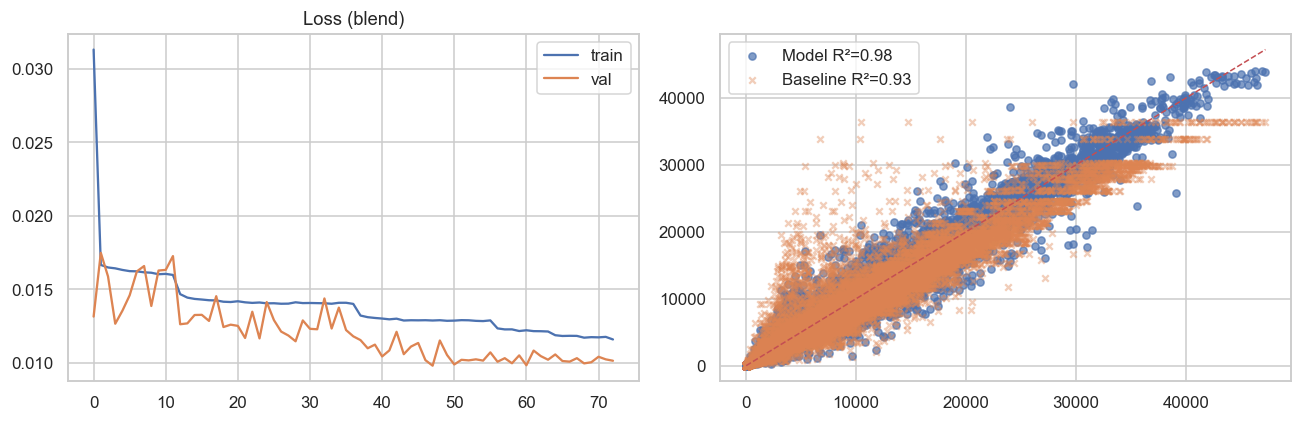

In [11]:
if TUNE_RESID_CLIP_ON_VAL:
    best_clip, best_mae = RESID_CLIP[1], float("inf")
    for clip_hi in RESID_CLIP_CANDIDATES:
        tmp_clip = (-clip_hi, clip_hi)
        pred_resid = model.predict(_fit_inputs(X_val_route, X_val_num), verbose=0).ravel()
        pred_resid = np.clip(pred_resid, *tmp_clip)
        pred_val = np.expm1(val_df["log_baseline"].values + pred_resid)
        mae_val = mean_absolute_error(val_df["demand"].values, pred_val)
        print(f"  val MAE @ clip ±{clip_hi:.2f}: {mae_val:,.1f}")
        if mae_val < best_mae:
            best_mae, best_clip = mae_val, clip_hi
    RESID_CLIP = (-best_clip, best_clip)
    print(f"→ Chọn RESID_CLIP = ±{best_clip:.2f} (val MAE={best_mae:,.1f})")


def _predict_resid_mlp(route_idx_arr, num_feat_arr):
    return model.predict(_fit_inputs(route_idx_arr, num_feat_arr), verbose=0).ravel()


blend_weight_tuned = False


def tune_blend_weight_mlp() -> None:
    """Chọn trọng số MLP/HistGBM trên val — chỉ chạy một lần."""
    global blend_weight_mlp, blend_weight_tuned
    if histgbm_model is None:
        return
    if blend_weight_tuned:
        return
    if HISTGBM_BLEND_WEIGHT is not None:
        blend_weight_mlp = float(HISTGBM_BLEND_WEIGHT)
        blend_weight_tuned = True
        return
    pred_mlp = np.clip(_predict_resid_mlp(X_val_route, X_val_num), *RESID_CLIP)
    pred_gbm = histgbm_model.predict(X_val_num)
    best_w, best_mae = 0.5, float("inf")
    for w in np.linspace(0.2, 0.8, 7):
        pr = srp.blend_residual_predictions(pred_mlp, pred_gbm, w)
        pv = srp.residuals_to_demand(val_df["log_baseline"].values, pr, RESID_CLIP)
        m = mean_absolute_error(val_df["demand"].values, pv)
        if m < best_mae:
            best_mae, best_w = m, w
    blend_weight_mlp = best_w
    blend_weight_tuned = True
    print(f"Blend val: MLP weight={blend_weight_mlp:.2f} (MAE={best_mae:,.1f})")


def predict_demand(route_idx_arr, num_feat_arr, log_baseline):
    pred_mlp = np.clip(_predict_resid_mlp(route_idx_arr, num_feat_arr), *RESID_CLIP)
    if histgbm_model is not None:
        pred_gbm = histgbm_model.predict(num_feat_arr)
        tune_blend_weight_mlp()
        pred_resid = srp.blend_residual_predictions(pred_mlp, pred_gbm, blend_weight_mlp)
    else:
        pred_resid = pred_mlp
    return srp.residuals_to_demand(log_baseline, pred_resid, RESID_CLIP)


y_pred = predict_demand(X_test_route, X_test_num, test_df["log_baseline"].values)

y_true = test_df["demand"].values
baseline_pred_test = test_df["baseline_demand"].values
m_base = srp.regression_metrics(y_true, baseline_pred_test)
m_nn = srp.regression_metrics(y_true, y_pred)
mae_impr = (m_base["mae"] - m_nn["mae"]) / m_base["mae"] * 100

nn_eval_metrics = {
    "holdout": {
        "test_block": f"{HOLDOUT_TEST_SEASON}_{HOLDOUT_TEST_YEAR}",
        "val_block": f"{HOLDOUT_VAL_SEASON}_{HOLDOUT_VAL_YEAR}",
        "n_test": int(len(test_df)),
        "model_type": "blend",
        "blend_mlp_weight": float(blend_weight_mlp) if histgbm_model is not None else None,
        "baseline": m_base,
        "model": m_nn,
        "mae_improvement_pct": float(mae_impr),
        "resid_clip": float(RESID_CLIP[1]),
    },
}

def _fmt(m):
    return f"MAE={m['mae']:,.0f} RMSE={m['rmse']:,.0f} R²={m['r2']:+.3f} MAPE={m['mape_pct']:.1f}% SMAPE={m['smape_pct']:.1f}%"

print("=== Hold-out test ===")
print(f"  {DEMAND_MODEL_TYPE} | test={HOLDOUT_TEST_SEASON}_{HOLDOUT_TEST_YEAR}")
print(f"  Baseline: {_fmt(m_base)}")
print(f"  Model:    {_fmt(m_nn)}  (ΔMAE {mae_impr:+.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
if "val_loss" in history.history:
    axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title(f"Loss ({DEMAND_MODEL_TYPE})")
axes[0].legend()
axes[1].scatter(y_true, y_pred, alpha=0.7, s=22, label=f"Model R²={m_nn['r2']:.2f}")
axes[1].scatter(y_true, baseline_pred_test, alpha=0.4, s=18, marker="x", label=f"Baseline R²={m_base['r2']:.2f}")
lim = max(y_true.max(), y_pred.max())
axes[1].plot([0, lim], [0, lim], "r--", lw=1)
axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_nn_eval.png", dpi=120, bbox_inches="tight")
plt.show()



In [12]:
all_df = df.copy()
if "month" not in all_df.columns:
    all_df["month"] = all_df["date"].dt.month
all_df = srp.add_cyclical_time_features(all_df)
all_df = srp.add_lag_features(all_df, use_lags=USE_LAG_FEATURES, lag_cols=LAG_FEATURE_COLS)
all_df = attach_baseline(all_df)
all_df = srp.fill_lag_from_train(all_df, train_df, lag_cols=LAG_FEATURE_COLS)
all_df["log_baseline"] = np.log1p(all_df["baseline_demand"])

dates_arr = np.array(sorted(all_df["date"].unique()))
season_cv_folds = srp.build_season_year_cv_folds(dates_arr, n_years=CV_SEASON_YEARS)
if not season_cv_folds:
    raise ValueError("Không đủ dữ liệu cho CV mùa×năm — cần ít nhất một ngày mỗi (mùa, năm)")
print(f"CV theo mùa×năm: {len(season_cv_folds)} fold (kỳ vọng tối đa {CV_SPLITS})")

cv_mae_nn, cv_mae_base, cv_rmse_nn, cv_rmse_base, cv_r2_nn, cv_r2_base = [], [], [], [], [], []
for fold, (tr_dates, te_dates, fold_label) in enumerate(season_cv_folds):
    tr_d = all_df[all_df["date"].isin(tr_dates)].copy()
    te_d = all_df[all_df["date"].isin(te_dates)].copy()
    if len(tr_d) == 0 or len(te_d) == 0:
        continue

    bl_lookup = (
        tr_d.groupby(["route_id", "hour", "is_weekend"])["demand"].median()
        .rename("baseline_demand_cv")
    )
    fb = tr_d.groupby(["route_id", "hour"])["demand"].median().rename("fb_demand")
    te_d = te_d.drop(columns=["baseline_demand", "log_baseline"], errors="ignore") \
                .merge(bl_lookup, on=["route_id", "hour", "is_weekend"], how="left") \
                .merge(fb, on=["route_id", "hour"], how="left")
    te_d["baseline_demand_cv"] = te_d["baseline_demand_cv"].fillna(te_d["fb_demand"])
    te_d = te_d.dropna(subset=["baseline_demand_cv"])
    te_d["log_baseline"] = np.log1p(te_d["baseline_demand_cv"])

    tr_d2 = tr_d.drop(columns=["baseline_demand", "log_baseline"], errors="ignore") \
                .merge(bl_lookup, on=["route_id", "hour", "is_weekend"], how="left") \
                .merge(fb, on=["route_id", "hour"], how="left")
    tr_d2["baseline_demand_cv"] = tr_d2["baseline_demand_cv"].fillna(tr_d2["fb_demand"])
    tr_d2 = tr_d2.dropna(subset=["baseline_demand_cv"])
    tr_d2["log_baseline"] = np.log1p(tr_d2["baseline_demand_cv"])

    sc = StandardScaler()
    Xt = sc.fit_transform(tr_d2[NUM_FEATURES])
    Xe = sc.transform(te_d[NUM_FEATURES])
    yt = np.log1p(tr_d2["demand"].values) - tr_d2["log_baseline"].values
    ye = te_d["demand"].values

    w_cv = np.ones(len(tr_d2), dtype=float)
    if PEAK_SAMPLE_WEIGHT > 1.0:
        pk = tr_d2["hour"].isin(PEAK_HOURS)
        w_cv[pk.to_numpy()] = PEAK_SAMPLE_WEIGHT

    sorted_tr = sorted(tr_dates)
    n_tune = max(1, int(len(sorted_tr) * CV_BLEND_TUNE_FRAC))
    tune_dates = set(sorted_tr[-n_tune:])
    fit_mask = ~tr_d2["date"].isin(tune_dates)
    tune_mask = tr_d2["date"].isin(tune_dates)

    m = make_demand_model(len(route_to_idx), len(NUM_FEATURES))
    m.fit(
        _fit_inputs(tr_d2.loc[fit_mask, "route_idx"].values.reshape(-1, 1), Xt[fit_mask]),
        yt[fit_mask],
        sample_weight=w_cv[fit_mask.to_numpy()],
        epochs=NN_EPOCHS_CV,
        batch_size=32,
        verbose=0,
        callbacks=[EarlyStopping(monitor="loss", patience=15, restore_best_weights=True)],
    )

    blend_w = 0.5
    hist_cv = None
    use_blend_cv = CV_USE_BLEND and USE_HISTGBM_BLEND
    if use_blend_cv:
        hist_cv = srp.fit_histgbm_demand(Xt[fit_mask], yt[fit_mask], sample_weight=w_cv[fit_mask.to_numpy()])
        pred_mlp_tune = m.predict(
            _fit_inputs(tr_d2.loc[tune_mask, "route_idx"].values.reshape(-1, 1), Xt[tune_mask]),
            verbose=0,
        ).ravel()
        pred_gbm_tune = hist_cv.predict(Xt[tune_mask])
        blend_w, _ = srp.tune_blend_weight_mae(
            pred_mlp_tune,
            pred_gbm_tune,
            tr_d2.loc[tune_mask, "log_baseline"].values,
            tr_d2.loc[tune_mask, "demand"].values,
            RESID_CLIP,
        )

    pred_mlp = m.predict(_fit_inputs(te_d["route_idx"].values.reshape(-1, 1), Xe), verbose=0).ravel()
    if use_blend_cv and hist_cv is not None:
        pred_resid = srp.blend_residual_predictions(pred_mlp, hist_cv.predict(Xe), blend_w)
    else:
        pred_resid = pred_mlp
    pred_resid = np.clip(pred_resid, *RESID_CLIP)
    pred_nn = np.expm1(te_d["log_baseline"].values + pred_resid)
    pred_base = te_d["baseline_demand_cv"].values

    mb = srp.regression_metrics(ye, pred_base)
    mn = srp.regression_metrics(ye, pred_nn)
    cv_mae_base.append(mb["mae"])
    cv_rmse_base.append(mb["rmse"])
    cv_r2_base.append(mb["r2"])
    cv_mae_nn.append(mn["mae"])
    cv_rmse_nn.append(mn["rmse"])
    cv_r2_nn.append(mn["r2"])
    tag = f"blend w={blend_w:.2f}"
    print(
        f"Fold {fold+1} ({fold_label}): train {len(tr_dates)} / test {len(te_dates)} dates  "
        f"| {tag} MAE={cv_mae_nn[-1]:,.0f} RMSE={cv_rmse_nn[-1]:,.0f} R²={cv_r2_nn[-1]:+.2f}  "
        f"| Baseline MAE={cv_mae_base[-1]:,.0f} RMSE={cv_rmse_base[-1]:,.0f}"
    )

cv_impr = (np.mean(cv_mae_base) - np.mean(cv_mae_nn)) / np.mean(cv_mae_base) * 100
print("\n=== 8-fold CV mùa×năm ===")
print(
    f"NN       MAE={np.mean(cv_mae_nn):,.0f}±{np.std(cv_mae_nn):,.0f}  "
    f"RMSE={np.mean(cv_rmse_nn):,.0f}±{np.std(cv_rmse_nn):,.0f}  R²={np.mean(cv_r2_nn):+.3f}"
)
print(
    f"Baseline MAE={np.mean(cv_mae_base):,.0f}±{np.std(cv_mae_base):,.0f}  "
    f"RMSE={np.mean(cv_rmse_base):,.0f}±{np.std(cv_rmse_base):,.0f}"
)
print(f"NN cải thiện trung bình so baseline: {cv_impr:+.1f}% MAE")

nn_cv_summary = {
    "cv_mode": "season_year",
    "cv_use_blend": bool(CV_USE_BLEND and USE_HISTGBM_BLEND),
    "n_folds": len(cv_mae_nn),
    "mae_nn_mean": float(np.mean(cv_mae_nn)),
    "rmse_nn_mean": float(np.mean(cv_rmse_nn)),
    "mae_baseline_mean": float(np.mean(cv_mae_base)),
    "rmse_baseline_mean": float(np.mean(cv_rmse_base)),
    "r2_nn_mean": float(np.mean(cv_r2_nn)),
    "r2_baseline_mean": float(np.mean(cv_r2_base)),
    "mae_improvement_pct": float(cv_impr),
}
nn_eval_metrics["cv"] = nn_cv_summary

_cv_key = {
"mae": ("mae_baseline_mean", "mae_nn_mean"),
"rmse": ("rmse_baseline_mean", "rmse_nn_mean"),
"r2": ("r2_baseline_mean", "r2_nn_mean"),
}
nn_report = pd.DataFrame(
[
    {
        "metric": k,
        "holdout_baseline": nn_eval_metrics["holdout"]["baseline"][k],
        "holdout_nn": nn_eval_metrics["holdout"]["model"][k],
        "cv_mean_baseline": nn_cv_summary.get(_cv_key[k][0]),
        "cv_mean_nn": nn_cv_summary.get(_cv_key[k][1]),
    }
    for k in ("mae", "rmse", "r2")
]
)
print("\nBảng tổng hợp NN (hold-out vs CV):")
print(nn_report.round(3).to_string(index=False))
nn_report.to_csv(OUT_DIR / "nn_eval_summary.csv", index=False)
print("Đã lưu:", OUT_DIR / "nn_eval_summary.csv")


CV theo mùa×năm: 8 fold (kỳ vọng tối đa 8)
Fold 1 (winter_2024): train 640 / test 91 dates  | blend w=0.00 MAE=550 RMSE=1,122 R²=+0.96  | Baseline MAE=997 RMSE=1,936
Fold 2 (spring_2024): train 639 / test 92 dates  | blend w=0.60 MAE=466 RMSE=845 R²=+0.98  | Baseline MAE=622 RMSE=1,200
Fold 3 (summer_2024): train 639 / test 92 dates  | blend w=0.00 MAE=465 RMSE=795 R²=+0.98  | Baseline MAE=888 RMSE=1,650
Fold 4 (autumn_2024): train 640 / test 91 dates  | blend w=0.20 MAE=488 RMSE=996 R²=+0.97  | Baseline MAE=794 RMSE=1,559
Fold 5 (winter_2025): train 641 / test 90 dates  | blend w=0.00 MAE=637 RMSE=1,129 R²=+0.96  | Baseline MAE=907 RMSE=1,842
Fold 6 (spring_2025): train 639 / test 92 dates  | blend w=0.00 MAE=542 RMSE=939 R²=+0.98  | Baseline MAE=864 RMSE=1,473
Fold 7 (summer_2025): train 639 / test 92 dates  | blend w=0.20 MAE=507 RMSE=874 R²=+0.98  | Baseline MAE=714 RMSE=1,344
Fold 8 (autumn_2025): train 640 / test 91 dates  | blend w=0.80 MAE=550 RMSE=1,062 R²=+0.97  | Baseline MA

## 4b. Quantile GBM (rainy_day p75)

Train HistGBM q75 cho kịch bản `rainy_day`. Lưu `quantile_gbm_q75.pkl`.


In [13]:
import pickle

log_base_test = test_df["log_baseline"].values
y_true_test = test_df["demand"].values

# MỚI — chỉ q75 được dùng trong rainy_day
quantile_models = srp.fit_quantile_gbm(
    X_train_num, y_train,
    quantiles=[0.75],
    sample_weight=train_weights,
)
qpred = srp.predict_quantile_gbm(quantile_models, X_test_num)
resid_p75 = np.clip(
    np.asarray(
        qpred.get("q75", qpred.get("p75", next(iter(qpred.values())))),
        dtype=float,
    ),
    *RESID_CLIP,
)
demand_p75_test = np.expm1(log_base_test + resid_p75)
mae_p75 = mean_absolute_error(y_true_test, demand_p75_test)
print(f"Quantile GBM q75 — MAE on test: {mae_p75:,.0f}")

with open(OUT_DIR / "quantile_gbm_q75.pkl", "wb") as f:
    pickle.dump(quantile_models, f)
print("Đã lưu:", OUT_DIR / "quantile_gbm_q75.pkl")


Quantile GBM q75 — MAE on test: 458
Đã lưu: outputs\default\quantile_gbm_q75.pkl


## 5. Bài toán tối ưu

- **Biến:** `trips[r,d,h]` trên `OPT_SCOPE`.
- **Mục tiêu:** min passenger-min wait + λ × tổng chuyến.
- **Bound:** dynamic baseline ∩ headway (peak / off-peak / overnight / rainy).
- **Ràng buộc §6:** service window, fleet route×dir, capacity floor, smoothness.


In [14]:
N_SLOTS = len(OPT_SCOPE)
print(f"Scope tối ưu: {len(OPT_ROUTES)} tuyến × {len(DIRECTIONS)} hướng × {len(OPT_HOURS)} giờ = {N_SLOTS} slots")

slot_to_idx = {s: i for i, s in enumerate(OPT_SCOPE)}
slot_route = np.array([s[0] for s in OPT_SCOPE])
slot_dir   = np.array([s[1] for s in OPT_SCOPE])
slot_hour  = np.array([s[2] for s in OPT_SCOPE])

hw_lookup = headway.set_index(["route_id", "direction_id", "hour"])["trip_count"]
hw_rd_median = headway.groupby(["route_id", "direction_id"])["trip_count"].median()
hw_rh_median = headway.groupby(["route_id", "hour"])["trip_count"].median()
hw_hour_median = headway.groupby("hour")["trip_count"].median()
hw_global_median = float(headway["trip_count"].median())

n_fallback = 0
fallback_tiers = []
baseline_trips = np.zeros(N_SLOTS)
for i, (r, d, h) in enumerate(OPT_SCOPE):
    if (r, d, h) in hw_lookup.index:
        baseline_trips[i] = hw_lookup.loc[(r, d, h)]
        fallback_tiers.append(0)
    elif (r, d) in hw_rd_median.index:
        baseline_trips[i] = hw_rd_median.loc[(r, d)]
        fallback_tiers.append(1)
        n_fallback += 1
    elif (r, h) in hw_rh_median.index:
        baseline_trips[i] = hw_rh_median.loc[(r, h)]
        fallback_tiers.append(2)
        n_fallback += 1
    elif h in hw_hour_median.index:
        baseline_trips[i] = hw_hour_median.loc[h]
        fallback_tiers.append(3)
        n_fallback += 1
    else:
        baseline_trips[i] = hw_global_median
        fallback_tiers.append(4)
        n_fallback += 1

print(f"Baseline trips: mean={baseline_trips.mean():.1f}, "
      f"min={baseline_trips.min():.0f}, max={baseline_trips.max():.0f}")
print(f"Headway fallback: {n_fallback}/{N_SLOTS} slots "
      f"(tier 0=exact GTFS, 1=route×dir, 2=route×hour, 3=hour, 4=global)")

_dyn_min, _dyn_max = srp.build_dynamic_bounds(
    baseline_trips,
    slot_hour,
    peak_factor=TRIPS_PEAK_MAX_FACTOR,
    offpeak_factor=TRIPS_OFFPEAK_MAX_FACTOR,
    overnight_factor=TRIPS_OVERNIGHT_MAX_FACTOR,
    min_factor=TRIPS_MIN_FACTOR,
    overnight_min_factor=TRIPS_OVERNIGHT_MIN_FACTOR,
    max_delta=TRIPS_MAX_DELTA,
)
_hw_min, _hw_max = srp.build_headway_trip_bounds_by_slot(
    slot_hour,
    min_headway_min=MIN_HEADWAY_MIN,
    max_headway_min=MAX_HEADWAY_MIN,
    overnight_max_headway_min=OVERNIGHT_MAX_HEADWAY_MIN,
)
TRIPS_MIN, TRIPS_MAX = srp.merge_trip_bounds(_dyn_min, _dyn_max, _hw_min, _hw_max)

cycle_times = srp.compute_route_direction_cycle_times(
    SCHEDULE_DIR,
    service_id=HEADWAY_SERVICE,
    turnaround_buffer_min=TURNAROUND_BUFFER_MIN,
)
cycle_times.to_csv(OUT_DIR / "route_direction_cycle_times.csv", index=False)
_ct_map = srp.cycle_times_to_map(cycle_times)
cycle_time_per_slot = np.array(
    [float(_ct_map.get((str(slot_route[i]), int(slot_dir[i])), 90.0)) for i in range(N_SLOTS)],
    dtype=float,
)
# max_system_fleet computed nhưng không dùng — system fleet cap removed; per-route cap đủ khi Pareto chạy per-route
fleet_by_route_dir, max_system_fleet = srp.compute_fleet_limits_from_baseline(
    baseline_trips, slot_route, slot_dir, slot_hour, cycle_times,
)
SYSTEM_FLEET_CAPACITY = float(max_system_fleet)
fleet_by_route_dir.to_csv(OUT_DIR / "baseline_fleet_by_route_dir.csv", index=False)

print(f"System fleet capacity (peak concurrent vehicles) = {SYSTEM_FLEET_CAPACITY:.0f}")
print(f"Headway bounds: MIN_HEADWAY={MIN_HEADWAY_MIN} min → trips_max≤{_hw_max[0]} | "
      f"MAX_HEADWAY={MAX_HEADWAY_MIN} min → trips_min≥{_hw_min[0]}")
print(f"Cycle time (route×dir): median={cycle_times['cycle_time_min'].median():.1f} min | "
      f"fleet cap: per route×dir only (system cap disabled)")
print(
    f"TRIPS bounds (dynamic ∩ headway): min×{TRIPS_MIN_FACTOR} (overnight×{TRIPS_OVERNIGHT_MIN_FACTOR}) & headway≥{MAX_HEADWAY_MIN}min | "
    f"max peak×{TRIPS_PEAK_MAX_FACTOR} … & headway≤{MIN_HEADWAY_MIN}min | delta=+{TRIPS_MAX_DELTA}"
)
print(f"TRIPS_MIN range: [{TRIPS_MIN.min()}, {TRIPS_MIN.max()}]")
print(f"TRIPS_MAX range: [{TRIPS_MAX.min()}, {TRIPS_MAX.max()}]")

print("Baseline bound theo giờ (peak / overnight / off_peak) — toàn mạng:")
_bh0 = srp.report_bound_status(
    baseline_trips, TRIPS_MIN, TRIPS_MAX, slot_hour, verbose=False
)["by_hour_group"]
for _, row in _bh0.iterrows():
    print(f"  {row['hour_group']:10s} n={int(row['n_slots']):4d} | "
          f"min={row['at_min_pct']:.0f}% max={row['at_max_pct']:.0f}% interior={row['interior_pct']:.0f}%")
print(f"Baseline total trips/day: {baseline_trips.sum():.0f} | max allowed: {TRIPS_MAX.sum():.0f} "
      f"(+{(TRIPS_MAX.sum()/baseline_trips.sum()-1)*100:.0f}%)")
# Tỷ lệ demand theo chiều (proxy từ cơ cấu chuyến GTFS baseline)
_dir_df = pd.DataFrame({
    "route_id": slot_route,
    "direction_id": slot_dir,
    "hour": slot_hour,
    "base_trips": baseline_trips,
})
_dir_sum = _dir_df.groupby(["route_id", "hour"])["base_trips"].transform("sum").clip(lower=1e-6)
direction_share = (_dir_df["base_trips"] / _dir_sum).to_numpy(dtype=float)
print(
    f"Direction share (route×hour): min={direction_share.min():.2f}, max={direction_share.max():.2f}, "
    f"mean={direction_share.mean():.2f}"
)



Scope tối ưu: 25 tuyến × 2 hướng × 24 giờ = 1104 slots
Baseline trips: mean=7.4, min=1, max=28
Headway fallback: 0/1104 slots (tier 0=exact GTFS, 1=route×dir, 2=route×hour, 3=hour, 4=global)
System fleet capacity (peak concurrent vehicles) = 1077
Headway bounds: MIN_HEADWAY=3.0 min → trips_max≤20 | MAX_HEADWAY=20.0 min → trips_min≥2
Cycle time (route×dir): median=128.0 min | fleet cap: per route×dir only (system cap disabled)
TRIPS bounds (dynamic ∩ headway): min×0.5 (overnight×0.32) & headway≥20.0min | max peak×1.4 … & headway≤3.0min | delta=+3
TRIPS_MIN range: [2, 14]
TRIPS_MAX range: [4, 20]
Baseline bound theo giờ (peak / overnight / off_peak) — toàn mạng:
  peak       n= 291 | min=2% max=2% interior=97%
  overnight  n= 335 | min=3% max=0% interior=97%
  off_peak   n= 478 | min=4% max=0% interior=96%
Baseline total trips/day: 8124 | max allowed: 11497 (+42%)
Direction share (route×hour): min=0.20, max=1.00, mean=0.50


In [15]:
def _scenario_context(scenario: str) -> tuple[int, int, int, int, int, pd.Series]:
    """Trả về (dow, is_weekend, is_rain, is_snow, is_holiday, median factors)."""
    if scenario == "weekday_peak":
        dow, is_wkd = 1, 0
        is_rain, is_snow, is_holiday = 0, 0, 0
        med = df.median(numeric_only=True)
    elif scenario == "weekend":
        dow, is_wkd = 5, 1
        is_rain, is_snow, is_holiday = 0, 0, 0
        med = df.median(numeric_only=True)
    elif scenario == "rainy_day":
        # RAINY_HOUR_BOOST (§1) áp demand sau predict trong get_scenario_demand
        dow, is_wkd = 1, 0
        is_holiday = 0
        rain_mask = pd.Series(False, index=df.index)
        if "is_rain" in df.columns:
            rain_mask = rain_mask | (df["is_rain"].fillna(0).astype(int) == 1)
        rain_ref = df[rain_mask] if rain_mask.any() else df
        is_rain = 1
        is_snow = int(pd.to_numeric(rain_ref.get("is_snow", 0), errors="coerce").fillna(0).median() > 0)
        med = rain_ref.median(numeric_only=True)
    else:
        raise ValueError(scenario)
    return dow, is_wkd, is_rain, is_snow, is_holiday, med


def build_scenario_features(scenario: str) -> pd.DataFrame:
    """Feature frame theo route×hour (một dòng / giờ / tuyến — không lặp chiều)."""
    dow, is_wkd, is_rain, is_snow, is_holiday, med = _scenario_context(scenario)
    seen: set[tuple[str, int]] = set()
    rows = []
    for (r, _d, h) in OPT_SCOPE:
        key = (r, h)
        if key in seen:
            continue
        seen.add(key)
        row = dict(
            route_id=r, hour=h, day_of_week=dow,
            is_weekend=is_wkd, is_us_holiday=is_holiday,
            hour_sin=np.sin(2 * np.pi * h / 24), hour_cos=np.cos(2 * np.pi * h / 24),
            dow_sin=np.sin(2 * np.pi * dow / 7), dow_cos=np.cos(2 * np.pi * dow / 7),
        )
        row["month"] = int(med.get("month", 6))
        for col in HOURLY_FACTOR_COLS:
            if col.startswith("is_"):
                row[col] = int(med.get(col, 0) > 0)
            else:
                row[col] = float(med.get(col, 0.0))
        row["is_rain"] = is_rain
        row["is_snow"] = is_snow
        if USE_LAG_FEATURES:
            defaults = lag_feature_defaults.get(f"{r}|{h}", {})
            row.update(
                log_lag_24h=float(defaults.get("log_lag_24h", 0.0)),
                log_lag_168h=float(defaults.get("log_lag_168h", 0.0)),
                log_rolling_7d=float(defaults.get("log_rolling_7d", 0.0)),
            )
        rows.append(row)
    feat = pd.DataFrame(rows)
    feat = srp.add_cyclical_time_features(feat)
    feat["route_idx"] = feat["route_id"].map(route_to_idx).astype(int)
    return feat


def _prepare_route_hour_features(feat_rh: pd.DataFrame) -> pd.DataFrame:
    """Baseline + feature matrix cho predict (point hoặc quantile)."""
    bl = feat_rh.merge(baseline_lookup, on=["route_id", "hour", "is_weekend"], how="left")
    bl = bl.merge(fallback, on=["route_id", "hour"], how="left")

    fb_route = (
        df.groupby(["route_id", "is_weekend"], as_index=False)["demand"]
        .median().rename(columns={"demand": "fb_route_weekend"})
    )
    fb_hour = (
        df.groupby(["hour", "is_weekend"], as_index=False)["demand"]
        .median().rename(columns={"demand": "fb_hour_weekend"})
    )
    fb_global = float(pd.to_numeric(df["demand"], errors="coerce").dropna().median())
    if not np.isfinite(fb_global) or fb_global <= 0:
        fb_global = 100.0

    bl = bl.merge(fb_route, on=["route_id", "is_weekend"], how="left")
    bl = bl.merge(fb_hour, on=["hour", "is_weekend"], how="left")
    bl["baseline_demand"] = (
        pd.to_numeric(bl["baseline_demand"], errors="coerce")
        .fillna(bl["fallback_demand"])
        .fillna(bl["fb_route_weekend"])
        .fillna(bl["fb_hour_weekend"])
        .fillna(fb_global)
        .clip(lower=1e-6)
    )

    for c in NUM_FEATURES:
        if c == "log_baseline":
            continue
        if c not in bl.columns:
            bl[c] = 0.0
        bl[c] = pd.to_numeric(bl[c], errors="coerce")
        med = float(pd.to_numeric(df[c], errors="coerce").median()) if c in df.columns else 0.0
        bl[c] = bl[c].fillna(med if np.isfinite(med) else 0.0)

    bl["log_baseline"] = np.log1p(bl["baseline_demand"])
    return bl


def _predict_route_hour_demand(feat_rh: pd.DataFrame) -> pd.DataFrame:
    """Dự báo demand route×hour; trả về cột route_id, hour, demand."""
    bl = _prepare_route_hour_features(feat_rh)
    Xn = scaler.transform(bl[NUM_FEATURES])
    pred = predict_demand(
        bl["route_idx"].values.reshape(-1, 1), Xn, bl["log_baseline"].values
    )
    fill = float(np.nanmedian(bl["baseline_demand"]))
    pred = np.clip(np.nan_to_num(pred, nan=fill), 0.0, None)
    return bl[["route_id", "hour"]].assign(demand=pred)


def _predict_route_hour_demand_quantile(
    feat_rh: pd.DataFrame,
    *,
    quantile: float = RISK_DEMAND_QUANTILE,
) -> pd.DataFrame:
    """Demand conservative từ quantile GBM (scenario mưa/cực đoan)."""
    bl = _prepare_route_hour_features(feat_rh)
    Xn = scaler.transform(bl[NUM_FEATURES])
    pred = srp.demand_from_quantile_gbm(
        quantile_models,
        Xn,
        bl["log_baseline"].values,
        quantile=float(quantile),
        resid_clip=RESID_CLIP,
    )
    fill = float(np.nanmedian(bl["baseline_demand"]))
    pred = np.clip(np.nan_to_num(pred, nan=fill), 0.0, None)
    return bl[["route_id", "hour"]].assign(demand=pred)


def allocate_demand_to_slots(route_hour: pd.DataFrame) -> np.ndarray:
    """Map demand route×hour → slot OPT_SCOPE; chia theo direction_share nếu bật."""
    rh = route_hour.set_index(["route_id", "hour"])["demand"]
    out = np.zeros(N_SLOTS, dtype=float)
    for i, (r, _d, h) in enumerate(OPT_SCOPE):
        d_rh = float(rh.get((r, h), np.nan))
        if not np.isfinite(d_rh):
            d_rh = float(rh.mean()) if len(rh) else 100.0
        if SPLIT_DEMAND_BY_DIRECTION:
            out[i] = d_rh * direction_share[i]
        else:
            out[i] = d_rh / max(len(DIRECTIONS), 1)
    return out


def get_scenario_demand(scenario: str) -> np.ndarray:
    feat_rh = build_scenario_features(scenario)
    use_quantile = (
        scenario in RISK_SCENARIOS
        and "quantile_models" in globals()
        and quantile_models is not None
    )
    if use_quantile:
        route_hour = _predict_route_hour_demand_quantile(feat_rh, quantile=RISK_DEMAND_QUANTILE)
    else:
        route_hour = _predict_route_hour_demand(feat_rh)
    if scenario == "rainy_day" and RAINY_HOUR_BOOST:
        route_hour["demand"] *= route_hour["hour"].map(RAINY_HOUR_BOOST).fillna(1.0)
    return allocate_demand_to_slots(route_hour)


SCENARIOS = ["weekday_peak", "weekend", "rainy_day"]
scenario_demand = {s: get_scenario_demand(s) for s in SCENARIOS}

_demand_src = {
    s: (f"quantile p{RISK_DEMAND_QUANTILE:.0%}" if s in RISK_SCENARIOS else "blend point")
    for s in SCENARIOS
}
print("Scenario demand source:", _demand_src)

_chk = build_scenario_features("rainy_day").iloc[0]
assert _chk["is_rain"] == 1
print("✓ rainy_day: is_rain=1, rain_mm elevated")

scen_df = pd.DataFrame({s: scenario_demand[s] for s in SCENARIOS})
scen_df.insert(0, "hour", slot_hour)
scen_df.insert(0, "dir", slot_dir)
scen_df.insert(0, "route", slot_route)

# Kiểm tra demand khác nhau giữa 2 chiều (cùng giờ)
_dir_cmp = scen_df.groupby(["hour", "dir"])["weekday_peak"].mean().unstack()
if _dir_cmp.shape[1] >= 2:
    ratio = (_dir_cmp.iloc[:, 1] / _dir_cmp.iloc[:, 0].clip(lower=1)).replace([np.inf], np.nan)
    print(f"Demand dir1/dir0 (weekday_peak, TB): min={ratio.min():.2f}, max={ratio.max():.2f}")

hour_agg = scen_df.groupby("hour")[SCENARIOS].mean().round(0)
print("\nDemand TB theo giờ (passengers/hour/slot, 3 kịch bản):")
print(hour_agg.head(8), "\n...", hour_agg.tail(3))
_ratio = scenario_demand["rainy_day"] / np.maximum(scenario_demand["weekday_peak"], 1e-9)
print("\nRainy / weekday_peak (TB):", round(float(_ratio.mean()), 3))





Scenario demand source: {'weekday_peak': 'blend point', 'weekend': 'blend point', 'rainy_day': 'quantile p75%'}
✓ rainy_day: is_rain=1, rain_mm elevated
Demand dir1/dir0 (weekday_peak, TB): min=0.82, max=1.39

Demand TB theo giờ (passengers/hour/slot, 3 kịch bản):
      weekday_peak  weekend  rainy_day
hour                                  
0            618.0    965.0      588.0
1            237.0    467.0      228.0
2            148.0    271.0      147.0
3            175.0    210.0      175.0
4            482.0    335.0      489.0
5           1537.0    617.0     1520.0
6           3362.0   1156.0     3292.0
7           6373.0   1726.0     6399.0 
...       weekday_peak  weekend  rainy_day
hour                                  
21          2409.0   2189.0     2417.0
22          2001.0   1992.0     1980.0
23          1235.0   1398.0     1231.0

Rainy / weekday_peak (TB): 1.049


In [16]:
CAPACITY_PER_TRIP = 1200


def evaluate_schedule(
    trips: np.ndarray,
    demand: np.ndarray,
    lambda_cost: float | None = None,
    *,
    capacity_per_trip: float = CAPACITY_PER_TRIP,
) -> dict:
    """Queue-based wait + vehicle-hours (f1/f2 for Pareto; no weighted-sum objective)."""
    trips = np.asarray(trips, dtype=float)
    demand = np.asarray(demand, dtype=float)
    trips = np.nan_to_num(trips, nan=1.0, posinf=60.0, neginf=1.0)
    demand = np.nan_to_num(demand, nan=0.0, posinf=0.0, neginf=0.0)
    trips = np.maximum(trips, 1)
    demand = np.clip(demand, 0.0, None)

    m = srp.compute_schedule_metrics(
        demand,
        trips,
        slot_route=slot_route,
        slot_dir=slot_dir,
        slot_hour=slot_hour,
        capacity_per_trip=capacity_per_trip,
        cycle_times=cycle_times,
        cost_per_vehicle_hour=COST_PER_VEHICLE_HOUR,
        system_fleet_capacity=globals().get("SYSTEM_FLEET_CAPACITY"),
    )
    headway_min = 60.0 / trips
    vh = float(m["total_vehicle_hours"])
    return dict(
        total_passenger_min_wait=float(m["total_passenger_min_wait"]),
        weighted_avg_wait_min=float(m["weighted_avg_wait_min"]),
        total_vehicle_hours=vh,
        total_fleet_cost=vh,  # legacy alias = vehicle-hours (not λ×trips)
        fleet_cost=float(m.get("fleet_cost", vh * COST_PER_VEHICLE_HOUR)),
        total_trips=float(m["total_trips"]),
        headway_std=float(headway_min.std()),
        overflow_pct=float(m["overflow_pct"]),
        total_overflow_pax=float(m["total_overflow_pax"]),
        max_queue_length=float(m["max_queue_length"]),
        slot_wait=m["slot_wait"],
        overflow_out=m["overflow_out"],
        queue_out=m["queue_out"],
        fleet_utilization=float(m["fleet_utilization"]) if "fleet_utilization" in m else None,
        system_fleet_capacity=float(m["system_fleet_capacity"]) if "system_fleet_capacity" in m else None,
    )


evaluate_schedule_v2 = evaluate_schedule  # backward compat


_peak_slot_mask = np.isin(slot_hour, PEAK_HOURS)


def _bind_at_max_frac(
    sol: np.ndarray,
    trips_max: np.ndarray,
    mask: np.ndarray | None = None,
) -> float:
    """Fraction of slots (or masked subset) at TRIPS_MAX."""
    sol = np.asarray(sol, dtype=int)
    tmax = np.asarray(trips_max, dtype=int)
    if mask is None:
        return float((sol >= tmax).mean())
    m = np.asarray(mask, dtype=bool)
    if not m.any():
        return 0.0
    return float((sol[m] >= tmax[m]).mean())


def trips_bounds_for_scenario(scenario: str) -> tuple[np.ndarray, np.ndarray]:
    """Per-scenario TRIPS_MIN/TRIPS_MAX (rainy peak floor + off-peak ceiling)."""
    return srp.trips_bounds_for_scenario(
        baseline_trips, slot_hour, TRIPS_MIN, TRIPS_MAX, scenario,
        rainy_peak_hours=tuple(RAINY_HOUR_BOOST.keys()),
        rainy_peak_min_factor=RAINY_PEAK_TRIPS_MIN_FACTOR,
        trips_min_factor=TRIPS_MIN_FACTOR,
        rainy_offpeak_max_factor=RAINY_OFFPEAK_MAX_FACTOR,
        peak_hours=PEAK_HOURS,
    )

def optimize_schedule_analytical(
    demand: np.ndarray,
    lambda_cost: float | None = None,
    trips_min: np.ndarray | None = None,
    trips_max: np.ndarray | None = None,
    cycle_time: np.ndarray | None = None,
) -> np.ndarray:
    """Pareto scan: min D·30/t + λ·(t·cycle/60) → t* = sqrt(1800·D/(λ·cycle))."""
    lam = LAMBDA_TRADEOFF if lambda_cost is None else float(lambda_cost)
    tmin = np.asarray(trips_min if trips_min is not None else TRIPS_MIN, dtype=float)
    tmax = np.asarray(trips_max if trips_max is not None else TRIPS_MAX, dtype=float)
    cyc = np.asarray(cycle_time if cycle_time is not None else cycle_time_per_slot, dtype=float)
    return srp.analytical_trips_per_slot(demand, lam, cyc, trips_min=tmin, trips_max=tmax)


def optimize_schedule_analytical_per_route(
    demand: np.ndarray,
    lambda_per_route: dict[str, float],
    trips_min: np.ndarray | None = None,
    trips_max: np.ndarray | None = None,
) -> np.ndarray:
    """Per-slot optimum with route-specific λ (from §5b_per_route knee)."""
    tmin = np.asarray(trips_min if trips_min is not None else TRIPS_MIN, dtype=float)
    tmax = np.asarray(trips_max if trips_max is not None else TRIPS_MAX, dtype=float)
    opt_trips = np.zeros(len(demand), dtype=int)
    for r in OPT_ROUTES:
        mask_r = slot_route == r
        if not mask_r.any():
            continue
        lam_r = float(lambda_per_route.get(r, LAMBDA_TRADEOFF))
        d_r = demand[mask_r]
        cyc_r = cycle_time_per_slot[mask_r]
        opt_trips[mask_r] = srp.analytical_trips_per_slot(
            d_r, lam_r, cyc_r, trips_min=tmin[mask_r], trips_max=tmax[mask_r]
        )
    return opt_trips


def summarize_bound_status(
    trips: np.ndarray,
    label: str = "",
    trips_min: np.ndarray | None = None,
    trips_max: np.ndarray | None = None,
) -> dict:
    tmin = TRIPS_MIN if trips_min is None else trips_min
    tmax = TRIPS_MAX if trips_max is None else trips_max
    return srp.report_bound_status(
        trips, tmin, tmax, slot_hour, label=label, verbose=bool(label)
    )


def calibrate_lambda_for_demand(
    demand: np.ndarray,
    lambda_lo: float = 80.0,
    lambda_hi: float = 2500.0,
    target_max_frac: float = 0.25,
    *,
    trips_min: np.ndarray | None = None,
    trips_max: np.ndarray | None = None,
    peak_only: bool = False,
    optimize_fn=None,
) -> float:
    tmin = TRIPS_MIN if trips_min is None else trips_min
    tmax = TRIPS_MAX if trips_max is None else trips_max
    mask = _peak_slot_mask if peak_only else None
    if optimize_fn is None:
        def optimize_fn(d, lc):
            return optimize_schedule_analytical(d, lambda_cost=lc, trips_min=tmin, trips_max=tmax)
    lo, hi = float(lambda_lo), float(lambda_hi)
    for _ in range(48):
        mid = (lo + hi) / 2.0
        sol = optimize_fn(demand, mid)
        at_max = _bind_at_max_frac(sol, tmax, mask)
        if at_max > target_max_frac:
            lo = mid
        else:
            hi = mid
    return hi



baseline_metrics = {s: evaluate_schedule(baseline_trips, scenario_demand[s])
                    for s in scenario_demand}
print("Baseline metrics (λ={}):".format(LAMBDA_COST))
for s, m in baseline_metrics.items():
    print(f"  {s:15s} | wait={m['total_passenger_min_wait']:>14,.0f} | "
          f"VH={m['total_vehicle_hours']:>12,.0f} | wait={m['total_passenger_min_wait']:>14,.0f} | trips={m['total_trips']:.0f}")


def pct_improve(base_val: float, new_val: float) -> float:
    """% cải thiện (base - new) / base, có guard chia 0."""
    base = float(base_val)
    return (base - float(new_val)) / max(base, 1e-9) * 100.0


def _lambda_knee_median() -> float:
    """Median λ knee across routes (§5b_per_route); fallback LAMBDA_COST."""
    lpr = globals().get("lambda_knee_per_route") or {}
    return float(np.median(list(lpr.values()))) if lpr else float(LAMBDA_COST)


def resolve_opt_policy(
    target: str | None = None,
    weights: dict | None = None,
    lambda_candidates: list[float] | None = None,
) -> tuple[str, tuple[float, float], list[float]]:
    """Chuẩn hóa policy tối ưu để dùng lại giữa các block."""
    opt_target = str(target if target is not None else "balanced").strip().lower()
    if opt_target not in {"wait", "cost", "balanced"}:
        opt_target = "balanced"

    cfg = weights if weights is not None else {"wait": 0.5, "cost": 0.5}
    w_wait = max(float(cfg.get("wait", 0.5)), 0.0)
    w_cost = max(float(cfg.get("cost", 0.5)), 0.0)
    if (w_wait + w_cost) <= 1e-9:
        w_wait, w_cost = 0.5, 0.5
    w_sum = w_wait + w_cost
    w_wait, w_cost = w_wait / w_sum, w_cost / w_sum

    lpr = globals().get("lambda_knee_per_route") or {}
    if lambda_candidates is not None:
        cands = [float(x) for x in lambda_candidates]
    elif lpr:
        cands = [_lambda_knee_median()]
    else:
        cands = [float(LAMBDA_COST)]
    if not cands:
        cands = [float(LAMBDA_COST)]

    return opt_target, (w_wait, w_cost), cands


def score_metrics(metrics: dict, base_metrics: dict, opt_target: str, weights: tuple[float, float]) -> float:
    """Tính score theo target policy."""
    if opt_target == "wait":
        return float(metrics["total_passenger_min_wait"])
    if opt_target == "cost":
        return float(metrics["total_vehicle_hours"])
    if opt_target == "balanced":
        w_wait, w_cost = weights
        wait_ratio = float(metrics["total_passenger_min_wait"]) / max(float(base_metrics["total_passenger_min_wait"]), 1e-9)
        vh_ratio = float(metrics["total_vehicle_hours"]) / max(float(base_metrics["total_vehicle_hours"]), 1e-9)
        return w_wait * wait_ratio + w_cost * vh_ratio
    return float(metrics["total_passenger_min_wait"])


def select_best_lambda_solution(
    demand: np.ndarray,
    baseline_trips_arr: np.ndarray,
    lambda_eval: float,
    opt_target: str,
    weights: tuple[float, float],
    lambda_candidates: list[float],
) -> tuple[np.ndarray, float, dict, dict, float]:
    """Quét lambda_opt và chọn nghiệm tốt nhất theo policy."""
    base_metrics = evaluate_schedule(baseline_trips_arr, demand, lambda_cost=lambda_eval)

    best_score = float("inf")
    best_sol = None
    best_lam = float(lambda_eval)
    best_eval = None

    for lam_opt in lambda_candidates:
        cand = optimize_schedule_analytical(demand, lambda_cost=lam_opt)
        cand = np.clip(cand, TRIPS_MIN, TRIPS_MAX).astype(int)
        m_eval = evaluate_schedule(cand, demand, lambda_cost=lambda_eval)
        score = score_metrics(m_eval, base_metrics, opt_target, weights)
        if score + 1e-9 < best_score:
            best_score = score
            best_sol = cand.copy()
            best_lam = float(lam_opt)
            best_eval = m_eval

    return best_sol, best_lam, best_eval, base_metrics, best_score



Baseline metrics (λ=655.0):
  weekday_peak    | wait=    14,426,913 | VH=      17,442 | wait=    14,426,913 | trips=8124
  weekend         | wait=    10,010,188 | VH=      17,442 | wait=    10,010,188 | trips=8124
  rainy_day       | wait=    16,215,217 | VH=      17,442 | wait=    16,215,217 | trips=8124


## 5b. Pareto per route

Chọn λ knee riêng từng tuyến → `lambda_knee_per_route` (§6 `USE_PER_ROUTE_LAMBDA`). Output: `pareto_per_route.csv`, `fig_pareto_{route}.png`, `fig_pareto_peak_routes.png`.



  1    λ_knee=   162 | f1_improve=+25.4% f2_delta=+34.0%
  2    λ_knee=    63 | f1_improve=+28.8% f2_delta=+42.6%
  3    λ_knee=    46 | f1_improve=+30.7% f2_delta=+48.0%
  4    λ_knee=   111 | f1_improve=+27.6% f2_delta=+39.4%
  5    λ_knee=   104 | f1_improve=+29.3% f2_delta=+41.5%
  6    λ_knee=   152 | f1_improve=+30.1% f2_delta=+31.9%
  7    λ_knee=   196 | f1_improve=+17.4% f2_delta=+21.3%
  A    λ_knee=    76 | f1_improve=+27.7% f2_delta=+36.4%
  B    λ_knee=   269 | f1_improve=+32.4% f2_delta=+45.9%
  C    λ_knee=    20 | f1_improve=+35.6% f2_delta=+48.6%
  D    λ_knee=   104 | f1_improve=+31.2% f2_delta=+45.9%
  E    λ_knee=   162 | f1_improve=+26.7% f2_delta=+36.8%
  F    λ_knee=   104 | f1_improve=+27.5% f2_delta=+37.9%
  FS   λ_knee=    49 | f1_improve=+34.9% f2_delta=+55.5%
  G    λ_knee=    63 | f1_improve=+29.7% f2_delta=+45.0%
  GS   λ_knee=   447 | f1_improve=+18.1% f2_delta=+22.6%
  H    λ_knee=    21 | f1_improve=+33.9% f2_delta=+36.9%
  J    λ_knee=    92 | f1_impro

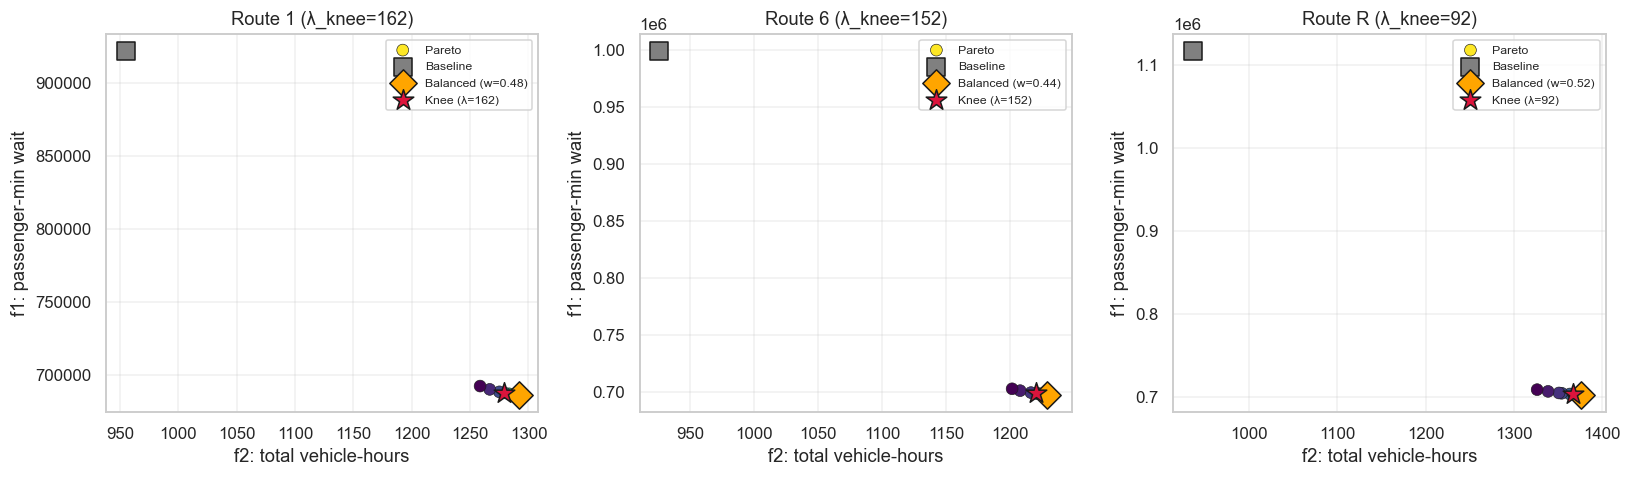

Đã lưu: outputs\default\fig_pareto_peak_routes.png


In [17]:
# §5b_per_route — Pareto frontier riêng cho từng route

lambda_knee_per_route: dict[str, float] = {}
pareto_dfs_per_route: dict[str, pd.DataFrame] = {}
pareto_summary_rows: list[dict] = []

_demand_peak = scenario_demand["weekday_peak"]


def make_opt_fn(tmin, tmax, cyc):
    def _opt(demand, lam):
        return srp.analytical_trips_per_slot(demand, lam, cyc, trips_min=tmin, trips_max=tmax)
    return _opt


def make_eval_fn(r_arr, d_arr, h_arr):
    def _eval(trips, demand, _lam_eval):
        return srp.compute_schedule_metrics(
            demand, trips,
            slot_route=r_arr, slot_dir=d_arr, slot_hour=h_arr,
            capacity_per_trip=float(CAPACITY_PER_TRIP),
            cycle_times=cycle_times,
        )
    return _eval


for r in OPT_ROUTES:
    mask_r = slot_route == r
    if mask_r.sum() == 0:
        continue

    demand_r = _demand_peak[mask_r]
    baseline_r = baseline_trips[mask_r]
    tmin_r = TRIPS_MIN[mask_r].copy()
    tmax_r = TRIPS_MAX[mask_r].copy()
    hour_r = slot_hour[mask_r]
    dir_r = slot_dir[mask_r]
    route_r = slot_route[mask_r]

    cyc_r = cycle_time_per_slot[mask_r]
    opt_fn_r = make_opt_fn(tmin_r, tmax_r, cyc_r)
    eval_fn_r = make_eval_fn(route_r, dir_r, hour_r)

    try:
        pareto_r = srp.generate_pareto_frontier(
            {"weekday_peak": demand_r},
            baseline_r,
            opt_fn_r,
            eval_fn_r,
            scenario="weekday_peak",
            n_points=PARETO_N_POINTS,
            lambda_eval=LAMBDA_TRADEOFF,
        )
        knee_r = srp.find_knee_point(pareto_r)
        lam_knee = float(knee_r["lambda_equiv"])
        lambda_knee_per_route[r] = lam_knee
        pareto_dfs_per_route[r] = pareto_r

        pareto_summary_rows.append(dict(
            route_id=r,
            n_slots=int(mask_r.sum()),
            lambda_knee=lam_knee,
            f1_knee=float(knee_r["f1"]),
            f2_knee=float(knee_r["f2"]),
            total_trips_knee=float(knee_r["total_trips"]),
            f1_improve_pct=float(knee_r.get("f1_improve_pct", float("nan"))),
            f2_delta_pct=float(knee_r.get("f2_delta_pct", float("nan"))),
        ))
        print(f"  {r:4s} λ_knee={lam_knee:6.0f} | "
              f"f1_improve={knee_r.get('f1_improve_pct', float('nan')):+.1f}% "
              f"f2_delta={knee_r.get('f2_delta_pct', float('nan')):+.1f}%")

        base_m = eval_fn_r(baseline_r.astype(int), demand_r, LAMBDA_COST)
        srp.plot_pareto_frontier(
            pareto_r,
            baseline_f1=float(base_m["total_passenger_min_wait"]),
            baseline_f2=float(base_m["total_vehicle_hours"]),
            title=f"Pareto — route {r} (weekday_peak)",
            save_path=OUT_DIR / f"fig_pareto_{r}.png",
            annotate_all=False,
        )
        plt.close()
    except Exception as e:
        print(f"  [WARN] route {r}: Pareto failed ({e}) — fallback λ={LAMBDA_COST}")
        lambda_knee_per_route[r] = float(LAMBDA_COST)

pareto_per_route = pd.DataFrame(pareto_summary_rows)
pareto_per_route.to_csv(OUT_DIR / "pareto_per_route.csv", index=False)
if len(pareto_per_route):
    print(f"\nPareto per route: {len(pareto_per_route)} routes, "
          f"λ range [{pareto_per_route['lambda_knee'].min():.0f}, "
          f"{pareto_per_route['lambda_knee'].max():.0f}]")
print("Đã lưu:", OUT_DIR / "pareto_per_route.csv")

pareto_df = pareto_per_route.copy()
if len(pareto_per_route):
    _knee_s = pareto_per_route.loc[
        pareto_per_route["lambda_knee"].sub(_lambda_knee_median()).abs().idxmin()
    ]
    knee_row = srp.json_default(_knee_s)
else:
    knee_row = {}

# Sync global λ default with empirical knee median (§5b → §6)
if lambda_knee_per_route:
    LAMBDA_TRADEOFF = float(_lambda_knee_median())
    LAMBDA_COST = LAMBDA_TRADEOFF
    print(f"LAMBDA_TRADEOFF ← median knee = {LAMBDA_TRADEOFF:.0f}")

# Peak hub routes: overlay Pareto (1, 6, R)
PEAK_PARETO_ROUTES = ("1", "6", "R")
fig, axes = plt.subplots(1, len(PEAK_PARETO_ROUTES), figsize=(5 * len(PEAK_PARETO_ROUTES), 4.5))
if len(PEAK_PARETO_ROUTES) == 1:
    axes = [axes]
for ax, r in zip(axes, PEAK_PARETO_ROUTES):
    if r not in pareto_dfs_per_route:
        ax.set_title(f"Route {r} (no data)")
        continue
    pdf = pareto_dfs_per_route[r]
    mask_r = slot_route == r
    demand_r = _demand_peak[mask_r]
    baseline_r = baseline_trips[mask_r]
    hour_r = slot_hour[mask_r]
    dir_r = slot_dir[mask_r]
    route_r = slot_route[mask_r]
    _eval = make_eval_fn(route_r, dir_r, hour_r)
    base_m = _eval(baseline_r.astype(int), demand_r, LAMBDA_TRADEOFF)
    srp.plot_pareto_frontier(
        pdf,
        baseline_f1=float(base_m["total_passenger_min_wait"]),
        baseline_f2=float(base_m["total_vehicle_hours"]),
        ax=ax,
        title=f"Route {r} (λ_knee={lambda_knee_per_route.get(r, float('nan')):.0f})",
        annotate_all=False,
    )
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_pareto_peak_routes.png", dpi=120, bbox_inches="tight")
plt.show()
print("Đã lưu:", OUT_DIR / "fig_pareto_peak_routes.png")



## 6. Tối ưu lịch trình

Analytical (λ theo route) → service window → ràng buộc fleet/capacity/smoothness.

Output: `schedule_{scenario}.csv`, `baseline_metrics.json`.


In [18]:
service_windows = srp.build_route_direction_departure_windows(
    SCHEDULE_DIR, service_id=HEADWAY_SERVICE
)
service_windows.to_csv(OUT_DIR / "service_windows.csv", index=False)
print(f"GTFS service windows: {len(service_windows)} (route×direction)")
print(service_windows.head(8).to_string(index=False))

def optimize_schedule_constrained(
    demand: np.ndarray,
    lambda_cost: float | None = None,
    lambda_per_route: dict[str, float] | None = None,
    trips_min: np.ndarray | None = None,
    trips_max: np.ndarray | None = None,
    *,
    use_route_fleet: bool = True,
    use_system_fleet: bool = False,
    use_capacity: bool = True,
    use_smoothness: bool = True,
) -> np.ndarray:
    """Analytical per-slot + service window + fleet/capacity/smoothness (§6)."""
    tmin = TRIPS_MIN if trips_min is None else trips_min
    tmax = TRIPS_MAX if trips_max is None else trips_max
    lpr = lambda_per_route if lambda_per_route is not None else globals().get("lambda_knee_per_route")
    if lpr:
        raw = optimize_schedule_analytical_per_route(
            demand, lambda_per_route=lpr, trips_min=tmin, trips_max=tmax
        )
    else:
        raw = optimize_schedule_analytical(
            demand, lambda_cost=lambda_cost, trips_min=tmin, trips_max=tmax
        )
    t = srp.apply_service_window_constraints(
        raw,
        slot_route=slot_route,
        slot_dir=slot_dir,
        slot_hour=slot_hour,
        windows=service_windows,
        baseline_trips=baseline_trips,
        trips_min=tmin,
        trips_max=tmax,
    )
    return srp.apply_optimizer_constraints(
        t,
        demand,
        slot_route=slot_route,
        slot_dir=slot_dir,
        slot_hour=slot_hour,
        cycle_times=cycle_times,
        fleet_by_route_dir=fleet_by_route_dir,
        max_system_fleet=None,
        capacity_per_trip=CAPACITY_PER_TRIP,
        max_overflow_pct=MAX_OVERFLOW_PCT,
        smoothness_max_delta=SMOOTHNESS_MAX_DELTA,
        trips_min=tmin,
        trips_max=tmax,
        use_route_fleet=use_route_fleet,
        use_system_fleet=use_system_fleet,
        use_capacity=use_capacity,
        use_smoothness=use_smoothness,
    )


def resolve_lambda_for_demand_constrained(
    demand: np.ndarray,
    lambda_cost: float,
    **kwargs,
) -> tuple[float, np.ndarray]:
    """Calibrate λ (ưu tiên peak bind) rồi tối ưu có ràng buộc GTFS."""
    auto = kwargs.get("auto_calibrate", LAMBDA_AUTO_CALIBRATE)
    target_global = kwargs.get("target_max_frac", TARGET_MAX_BIND_FRACTION)
    target_peak = kwargs.get("target_peak_frac", TARGET_PEAK_BIND_FRACTION)
    tmin = kwargs.get("trips_min", TRIPS_MIN)
    tmax = kwargs.get("trips_max", TRIPS_MAX)
    lpr = kwargs.get("lambda_per_route", globals().get("lambda_knee_per_route"))
    use_per_route = kwargs.get(
        "use_per_route_lambda",
        bool(globals().get("USE_PER_ROUTE_LAMBDA")) and bool(globals().get("lambda_knee_per_route")),
    )

    if use_per_route and lpr:
        lam_repr = float(np.median(list(lpr.values())))
        sol = optimize_schedule_constrained(
            demand, lambda_per_route=lpr, trips_min=tmin, trips_max=tmax
        )
        return lam_repr, sol

    def _opt(d, lc):
        return optimize_schedule_constrained(
            d, lambda_cost=lc, trips_min=tmin, trips_max=tmax
        )

    lam = float(lambda_cost)
    sol = _opt(demand, lam)
    if not auto:
        return lam, sol

    peak_at_max = _bind_at_max_frac(sol, tmax, _peak_slot_mask)
    if peak_at_max > target_peak:
        lam = calibrate_lambda_for_demand(
            demand,
            lambda_lo=lam,
            target_max_frac=target_peak,
            trips_min=tmin,
            trips_max=tmax,
            peak_only=True,
            optimize_fn=_opt,
        )
        sol = _opt(demand, lam)
    elif _bind_at_max_frac(sol, tmax) > target_global:
        lam = calibrate_lambda_for_demand(
            demand,
            lambda_lo=lam,
            target_max_frac=target_global,
            trips_min=tmin,
            trips_max=tmax,
            peak_only=False,
            optimize_fn=_opt,
        )
        sol = _opt(demand, lam)
    return lam, sol



GTFS service windows: 58 (route×direction)
route_id  direction_id  first_dep_min  last_dep_min first_dep_time last_dep_time  first_hour  last_hour  n_trips
       1             0           74.5        1499.0       01:14:00      24:59:00           1          0      231
       1             1            6.5        1432.5       00:06:00      23:52:00           0         23      231
       2             0          153.5        1573.5       02:34:00      26:14:00           2          2      162
       2             1           19.0        1439.0       00:19:00      23:59:00           0         23      162
       3             0           45.5        1465.0       00:46:00      24:25:00           0          0      151
       3             1            4.5        1430.5       00:04:00      23:50:00           0         23      151
       4             0          107.0        1527.0       01:47:00      25:27:00           1          1      184
       4             1            7.5        1427.5  

In [19]:
opt_results = {}
lambda_used = {}
bound_status = {}
bound_by_hour = {}
import time

print(f"Optimizer: Analytical (per-route λ knee) | N_SLOTS={N_SLOTS}")
if lambda_knee_per_route:
    print(f"  λ knee median={_lambda_knee_median():.0f} | per-route range "
          f"[{min(lambda_knee_per_route.values()):.0f}, {max(lambda_knee_per_route.values()):.0f}]")

for scen, dem in scenario_demand.items():
    t0 = time.time()
    opt_target, weights, lam_cands = resolve_opt_policy()
    tmin, tmax = trips_bounds_for_scenario(scen)
    if len(lam_cands) == 1:
        lam, opt_results[scen] = resolve_lambda_for_demand_constrained(
            dem, float(lam_cands[0]),
            trips_min=tmin, trips_max=tmax,
            auto_calibrate=not bool(lambda_knee_per_route),
        )
    elif opt_target in ("wait", "cost", "balanced") and len(lam_cands) > 1:
        best_sol, lam, m_eval, _, _ = select_best_lambda_solution(
            dem, baseline_trips, LAMBDA_COST, opt_target, weights, lam_cands
        )
        best_sol = srp.apply_service_window_constraints(
            best_sol,
            slot_route=slot_route, slot_dir=slot_dir, slot_hour=slot_hour,
            windows=service_windows,
            baseline_trips=baseline_trips, trips_min=TRIPS_MIN, trips_max=TRIPS_MAX,
        )
        opt_results[scen] = best_sol
    else:
        lam, opt_results[scen] = resolve_lambda_for_demand_constrained(dem, LAMBDA_COST)
    bound_status[scen] = summarize_bound_status(
        opt_results[scen], label=f"{scen} final λ={lam:.0f}",
        trips_min=tmin, trips_max=tmax,
    )
    bound_by_hour[scen] = bound_status[scen]["by_hour_group"].to_dict(orient="records")
    lambda_used[scen] = {
        "median": float(lam),
        "per_route": {str(k): float(v) for k, v in lambda_knee_per_route.items()} if lambda_knee_per_route else None,
        "mode": "per_route" if lambda_knee_per_route and USE_PER_ROUTE_LAMBDA else "global",
    }
    m = evaluate_schedule(opt_results[scen], dem, lambda_cost=LAMBDA_COST)
    base_wait = baseline_metrics[scen]["total_passenger_min_wait"]
    impr = pct_improve(base_wait, m["total_passenger_min_wait"])
    label = "Analytical"
    lam_label = (
        f"λ per-route (med={lam:.0f})"
        if lambda_knee_per_route and USE_PER_ROUTE_LAMBDA
        else f"λ={lam:.0f}"
    )
    util_str = (
        f" | fleet util={m['fleet_utilization']*100:.1f}%"
        if m.get("fleet_utilization") is not None
        else ""
    )
    print(f"[{scen:14s}] {label} wait={m['total_passenger_min_wait']:>14,.0f} (impr {impr:+.2f}%) "
          f"VH={m['total_vehicle_hours']:,.0f}{util_str} trips={m['total_trips']:.0f} {lam_label} [{time.time()-t0:.2f}s]")

_sched = pd.DataFrame({
    "route": slot_route, "direction": slot_dir, "hour": slot_hour,
    "baseline_trips": baseline_trips,
    "opt_trips": opt_results["weekday_peak"],
    "demand_pred": scenario_demand["weekday_peak"],
})
_sched = _sched.merge(
    service_windows.rename(columns={"route_id": "route", "direction_id": "direction"}),
    on=["route", "direction"], how="left",
)
_sched.to_csv(OUT_DIR / "schedule_weekday_peak.csv", index=False)
print("Đã lưu:", OUT_DIR / "schedule_weekday_peak.csv", "|", OUT_DIR / "service_windows.csv")




Optimizer: Analytical (per-route λ knee) | N_SLOTS=1104
  λ knee median=92 | per-route range [20, 447]
  [weekday_peak final λ=92] at TRIPS_MIN=1% | TRIPS_MAX=34% | interior=65% ✓ (target>60%)
    peak       n= 291 | min=1% max=20% interior=80% ✓
    overnight  n= 335 | min=2% max=39% interior=59%
    off_peak   n= 478 | min=1% max=38% interior=61%
[weekday_peak  ] Analytical wait=    12,297,800 (impr +14.76%) VH=20,796 | fleet util=80.4% trips=9581 λ per-route (med=92) [0.21s]
  [weekend final λ=92] at TRIPS_MIN=1% | TRIPS_MAX=36% | interior=63% ✓ (target>60%)
    peak       n= 291 | min=1% max=18% interior=81% ✓
    overnight  n= 335 | min=2% max=50% interior=48%
    off_peak   n= 478 | min=0% max=38% interior=62%
[weekend       ] Analytical wait=     8,403,019 (impr +16.06%) VH=20,894 | fleet util=80.8% trips=9600 λ per-route (med=92) [0.23s]
  [rainy_day final λ=92] at TRIPS_MIN=1% | TRIPS_MAX=31% | interior=68% ✓ (target>60%)
    peak       n= 291 | min=2% max=22% interior=76% ✓
 

## 6b. Ablation ràng buộc

So sánh từng lớp ràng buộc trên `weekday_peak`.


In [20]:
def _pct_at_bound(trips_arr: np.ndarray, tmin: np.ndarray, tmax: np.ndarray) -> float:
  t = np.asarray(trips_arr, dtype=int)
  at_min = (t <= np.asarray(tmin, dtype=int)).mean()
  at_max = (t >= np.asarray(tmax, dtype=int)).mean()
  return float((at_min + at_max) * 100.0)


def _optimize_ablation_stage(
  demand: np.ndarray,
  lam: float,
  *,
  use_headway_bounds: bool,
  use_route_fleet: bool,
  use_system_fleet: bool,
  use_capacity: bool,
  use_smoothness: bool,
) -> np.ndarray:
  tmin, tmax = TRIPS_MIN, TRIPS_MAX
  if not use_headway_bounds:
    tmin, tmax = _dyn_min, _dyn_max
  raw = optimize_schedule_analytical(demand, lambda_cost=lam, trips_min=tmin, trips_max=tmax)
  t = srp.apply_service_window_constraints(
    raw,
    slot_route=slot_route,
    slot_dir=slot_dir,
    slot_hour=slot_hour,
    windows=service_windows,
    baseline_trips=baseline_trips,
    trips_min=tmin,
    trips_max=tmax,
  )
  return srp.apply_optimizer_constraints(
    t,
    demand,
    slot_route=slot_route,
    slot_dir=slot_dir,
    slot_hour=slot_hour,
    cycle_times=cycle_times,
    fleet_by_route_dir=fleet_by_route_dir,
    max_system_fleet=None,
    capacity_per_trip=CAPACITY_PER_TRIP,
    max_overflow_pct=MAX_OVERFLOW_PCT,
    smoothness_max_delta=SMOOTHNESS_MAX_DELTA,
    trips_min=tmin,
    trips_max=tmax,
    use_route_fleet=use_route_fleet,
    use_system_fleet=use_system_fleet,
    use_capacity=use_capacity,
    use_smoothness=use_smoothness,
  )


_dem_ab = scenario_demand["weekday_peak"]
_lu_ab = lambda_used.get("weekday_peak", LAMBDA_TRADEOFF)
_lam_ab = float(_lu_ab["median"] if isinstance(_lu_ab, dict) else _lu_ab)
_ablation_stages = [
  ("baseline (service_window only)", dict(use_headway_bounds=False, use_route_fleet=False, use_system_fleet=False, use_capacity=False, use_smoothness=False)),
  ("+ headway bounds", dict(use_headway_bounds=True, use_route_fleet=False, use_system_fleet=False, use_capacity=False, use_smoothness=False)),
  ("+ turnaround/fleet-per-RD", dict(use_headway_bounds=True, use_route_fleet=True, use_system_fleet=False, use_capacity=False, use_smoothness=False)),
  ("+ capacity floor", dict(use_headway_bounds=True, use_route_fleet=True, use_system_fleet=False, use_capacity=True, use_smoothness=False)),
  ("+ smoothness (full)", dict(use_headway_bounds=True, use_route_fleet=True, use_system_fleet=False, use_capacity=True, use_smoothness=True)),
]
_ab_rows = []
for label, flags in _ablation_stages:
  sol = _optimize_ablation_stage(_dem_ab, _lam_ab, **flags)
  tmin_ab, tmax_ab = (TRIPS_MIN, TRIPS_MAX) if flags["use_headway_bounds"] else (_dyn_min, _dyn_max)
  m = evaluate_schedule(sol, _dem_ab)
  _ab_rows.append(dict(
    stage=label,
    total_vehicle_hours=m["total_vehicle_hours"],
    total_passenger_min_wait=m["total_passenger_min_wait"],
    overflow_pct=m["overflow_pct"],
    max_queue_length=m["max_queue_length"],
    pct_at_bound=_pct_at_bound(sol, tmin_ab, tmax_ab),
  ))
constraint_ablation_df = pd.DataFrame(_ab_rows)
constraint_ablation_df.to_csv(OUT_DIR / "constraint_ablation_weekday_peak.csv", index=False)
print("=== Constraint ablation (weekday_peak) ===")
print(constraint_ablation_df.round(2).to_string(index=False))
print("Đã lưu:", OUT_DIR / "constraint_ablation_weekday_peak.csv")


=== Constraint ablation (weekday_peak) ===
                         stage  total_vehicle_hours  total_passenger_min_wait  overflow_pct  max_queue_length  pct_at_bound
baseline (service_window only)             22515.23               11210953.44          0.27           2358.43         66.49
              + headway bounds             22360.17               11295645.84          0.36           2358.43         68.57
     + turnaround/fleet-per-RD             20985.17               12232518.75          0.91           2990.70         40.94
              + capacity floor             21016.48               12110186.67          0.09            590.70         41.12
           + smoothness (full)             20808.67               12290943.22          0.45           3986.86         38.13
Đã lưu: outputs\default\constraint_ablation_weekday_peak.csv


### Ràng buộc (tóm tắt)

| Ràng buộc | Mô tả ngắn |
|-----------|------------|
| Service window | First/last departure GTFS |
| Headway bounds | MIN/MAX headway → trips_min/max |
| Fleet route×dir | Little's law + cycle time |
| Capacity floor | trips ≥ ceil(demand / 1200) |
| Smoothness | \|Δtrips\| ≤ `SMOOTHNESS_MAX_DELTA` |

System fleet cap đã bỏ; Pareto giải theo từng route.


## 7. Queue metrics (operations)

Báo cáo chờ hàng đợi, overflow, vehicle-hours (upgrade_model.md §3–§4).



[baseline  ] wait=    14,426,913 pax-min | avg=3.56 min | VH=17,442 | overflow slots=1.5% | max queue=5,391 pax | fleet util=67.4%
[optimized ] wait=    12,297,800 pax-min | avg=3.03 min | VH=20,796 | overflow slots=0.5% | max queue=3,987 pax | fleet util=80.4%

Wait reduction: +14.76% | Vehicle-hours change: +19.23%


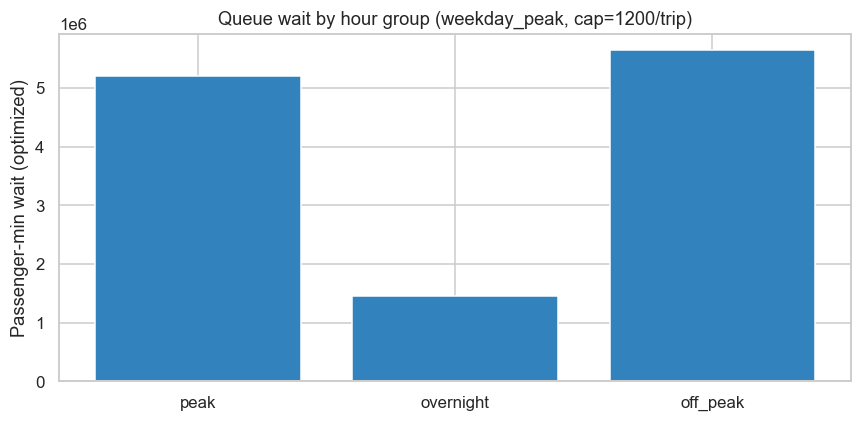

Đã lưu: outputs\default\wait_metric_comparison.csv


In [21]:
dem_peak = scenario_demand["weekday_peak"]
trips_opt = opt_results["weekday_peak"]

for label, trips_arr in [("baseline", baseline_trips), ("optimized", trips_opt)]:
    m = evaluate_schedule(trips_arr, dem_peak)
    print(
        f"[{label:10s}] wait={m['total_passenger_min_wait']:>14,.0f} pax-min | "
        f"avg={m['weighted_avg_wait_min']:.2f} min | VH={m['total_vehicle_hours']:,.0f} | "
        f"overflow slots={m['overflow_pct']:.1f}% | max queue={m['max_queue_length']:,.0f} pax"
        + (f" | fleet util={m['fleet_utilization']*100:.1f}%" if m.get('fleet_utilization') else "")
    )

m_base = evaluate_schedule(baseline_trips, dem_peak)
m_opt = evaluate_schedule(trips_opt, dem_peak)
wait_impr = pct_improve(m_base["total_passenger_min_wait"], m_opt["total_passenger_min_wait"])
vh_delta = (m_opt["total_vehicle_hours"] - m_base["total_vehicle_hours"]) / max(m_base["total_vehicle_hours"], 1e-9) * 100
print(f"\nWait reduction: {wait_impr:+.2f}% | Vehicle-hours change: {vh_delta:+.2f}%")

grp = srp.wait_totals_by_hour_groups(m_opt["slot_wait"], slot_hour)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(grp["hour_group"], grp["total_wait"], color="#3182bd")
ax.set_ylabel("Passenger-min wait (optimized)")
ax.set_title(f"Queue wait by hour group (weekday_peak, cap={CAPACITY_PER_TRIP}/trip)")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_wait_metric_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

wait_metric_cmp = pd.DataFrame([
    dict(schedule="baseline", **{k: m_base[k] for k in (
        "total_passenger_min_wait", "weighted_avg_wait_min", "total_vehicle_hours",
        "overflow_pct", "total_overflow_pax", "max_queue_length",
    )}),
    dict(schedule="optimized", **{k: m_opt[k] for k in (
        "total_passenger_min_wait", "weighted_avg_wait_min", "total_vehicle_hours",
        "overflow_pct", "total_overflow_pax", "max_queue_length",
    )}),
])
wait_metric_cmp["wait_improve_pct"] = np.nan
wait_metric_cmp.loc[wait_metric_cmp["schedule"] == "optimized", "wait_improve_pct"] = wait_impr
wait_metric_cmp["vehicle_hours_delta_pct"] = np.nan
wait_metric_cmp.loc[wait_metric_cmp["schedule"] == "optimized", "vehicle_hours_delta_pct"] = vh_delta
if m_base.get("fleet_utilization") is not None:
    wait_metric_cmp["fleet_utilization_pct"] = [
        m_base.get("fleet_utilization", np.nan) * 100,
        m_opt.get("fleet_utilization", np.nan) * 100,
    ]
wait_metric_cmp.to_csv(OUT_DIR / "wait_metric_comparison.csv", index=False)
print("Đã lưu:", OUT_DIR / "wait_metric_comparison.csv")





## 8. Đánh giá tổng hợp

Baseline GTFS vs optimized theo từng kịch bản.


In [ ]:
rows = []
for scen in scenario_demand:
    dem = scenario_demand[scen]
    base_wait = baseline_metrics[scen]["total_passenger_min_wait"]
    method_sols = [("Baseline", baseline_trips), ("Analytical", opt_results[scen])]
    for method, sol in method_sols:
        m = evaluate_schedule(sol, dem)
        base_vh = baseline_metrics[scen]["total_vehicle_hours"]
        rows.append(dict(
            scenario=scen, method=method, n_slots=N_SLOTS,
            total_passenger_min_wait=m["total_passenger_min_wait"],
            total_vehicle_hours=m["total_vehicle_hours"],
            weighted_avg_wait_min=m["weighted_avg_wait_min"],
            headway_std=m["headway_std"],
            total_trips=m["total_trips"],
            overflow_pct=m["overflow_pct"],
            max_queue_length=m["max_queue_length"],
            wait_saved_vs_baseline=base_wait - m["total_passenger_min_wait"],
            vehicle_hours_delta_vs_baseline=m["total_vehicle_hours"] - base_vh,
            fleet_utilization=m.get("fleet_utilization"),
        ))

results_df = pd.DataFrame(rows)
base_vh_per_scen = results_df[results_df["method"] == "Baseline"].set_index("scenario")["total_vehicle_hours"]
base_wait_per_scen = results_df[results_df["method"] == "Baseline"].set_index("scenario")["total_passenger_min_wait"]
results_df["wait_improvement_pct"] = results_df.apply(
    lambda r: (base_wait_per_scen[r["scenario"]] - r["total_passenger_min_wait"]) / base_wait_per_scen[r["scenario"]] * 100, axis=1)
results_df["vehicle_hours_change_pct"] = results_df.apply(
    lambda r: (r["total_vehicle_hours"] - base_vh_per_scen[r["scenario"]]) / base_vh_per_scen[r["scenario"]] * 100, axis=1)
base_util_per_scen = results_df[results_df["method"] == "Baseline"].set_index("scenario")["fleet_utilization"]
results_df["fleet_utilization_pct"] = results_df["fleet_utilization"] * 100.0
results_df["fleet_utilization_delta_pp"] = results_df.apply(
    lambda r: (float(r["fleet_utilization"] or 0) - float(base_util_per_scen.get(r["scenario"], 0) or 0)) * 100.0,
    axis=1,
)

def _lambda_used_label(scen):
    lu = lambda_used.get(scen, LAMBDA_TRADEOFF)
    if isinstance(lu, dict):
        return f"per-route(med={lu.get('median', 0):.0f})"
    return f"{float(lu):.0f}"

_lam_note = ", ".join(f"{s}={_lambda_used_label(s)}" for s in scenario_demand)
print(f"=== Kết quả (Analytical, λ_tradeoff scan, λ_opt: {_lam_note}, {N_SLOTS} slots) ===")
print(results_df.round(3).to_string(index=False))
results_df.to_csv(OUT_DIR / "results_summary.csv", index=False)

tradeoff_df = results_df[results_df["method"] == "Analytical"]
tradeoff_show = tradeoff_df[[
    "scenario", "wait_saved_vs_baseline", "vehicle_hours_delta_vs_baseline",
    "wait_improvement_pct", "vehicle_hours_change_pct", "total_trips",
]].rename(columns={
    "wait_saved_vs_baseline": "passenger_min_wait_saved",
    "vehicle_hours_delta_vs_baseline": "vehicle_hours_increase",
})
print("\n=== Trade-off Analytical vs Baseline ===")
print(tradeoff_show.round(0).to_string(index=False))
tradeoff_show.to_csv(OUT_DIR / "tradeoff_summary.csv", index=False)

_bound_rows = [{"scenario": scen, **row} for scen, rows in bound_by_hour.items() for row in rows]
if _bound_rows:
    pd.DataFrame(_bound_rows).to_csv(OUT_DIR / "bound_by_hour.csv", index=False)
    print("Đã lưu:", OUT_DIR / "bound_by_hour.csv")


=== Kết quả (Analytical, λ_tradeoff scan, λ_opt: weekday_peak=per-route(med=92), weekend=per-route(med=92), rainy_day=per-route(med=92), 1104 slots) ===
    scenario     method  n_slots  total_passenger_min_wait  total_vehicle_hours  weighted_avg_wait_min  headway_std  total_trips  overflow_pct  max_queue_length  wait_saved_vs_baseline  vehicle_hours_delta_vs_baseline  fleet_utilization  wait_improvement_pct  vehicle_hours_change_pct  fleet_utilization_pct  fleet_utilization_delta_pp
weekday_peak   Baseline     1104              14426912.892            17442.300                  3.560        6.224       8124.0         1.540          5390.696                   0.000                            0.000              0.674                 0.000                     0.000                 67.450                       0.000
weekday_peak Analytical     1104              12297800.065            20795.683                  3.034        4.242       9581.0         0.453          3986.865             21

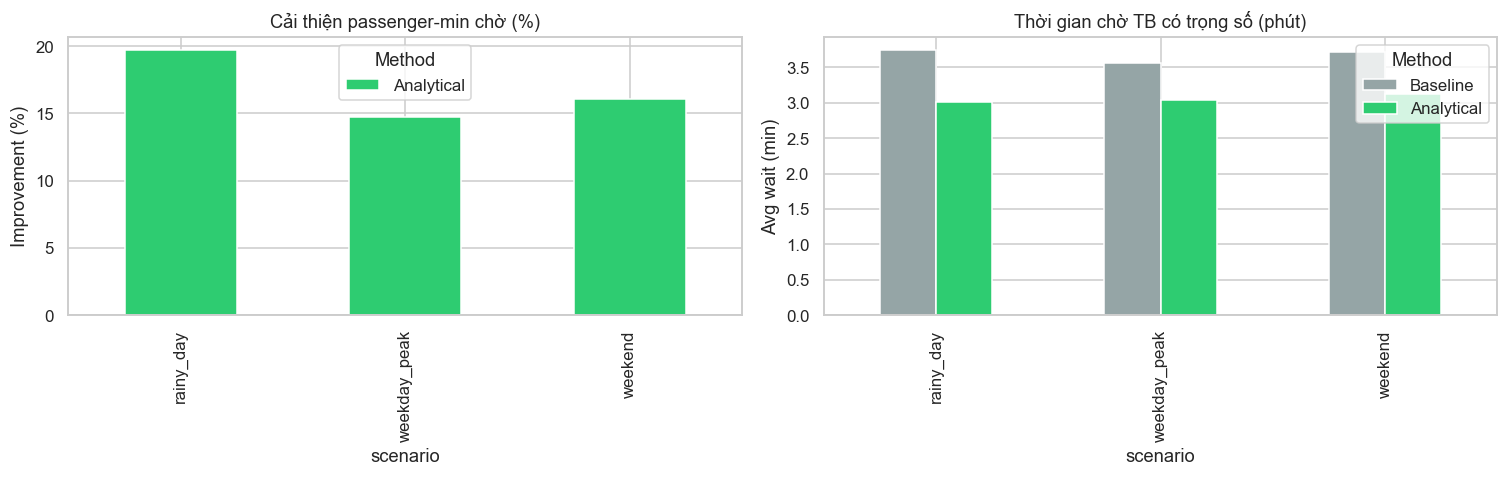

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

best_label = "Analytical"
methods_impr = [best_label]
pivot = results_df.pivot(index="scenario", columns="method", values="wait_improvement_pct")
pivot = pivot[[c for c in methods_impr if c in pivot.columns]]
pivot.plot(kind="bar", ax=axes[0], color=["#2ECC71"])
axes[0].set_title("Cải thiện passenger-min chờ (%)")
axes[0].set_ylabel("Improvement (%)"); axes[0].legend(title="Method")

cols_wait = ["Baseline", best_label]
pivot2 = results_df.pivot(index="scenario", columns="method", values="weighted_avg_wait_min")[cols_wait]
pivot2.plot(kind="bar", ax=axes[1], color=["#95A5A6", "#2ECC71"])
axes[1].set_title("Thời gian chờ TB có trọng số (phút)")
axes[1].set_ylabel("Avg wait (min)"); axes[1].legend(title="Method")

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_improvement.png", dpi=120, bbox_inches="tight")
plt.show()


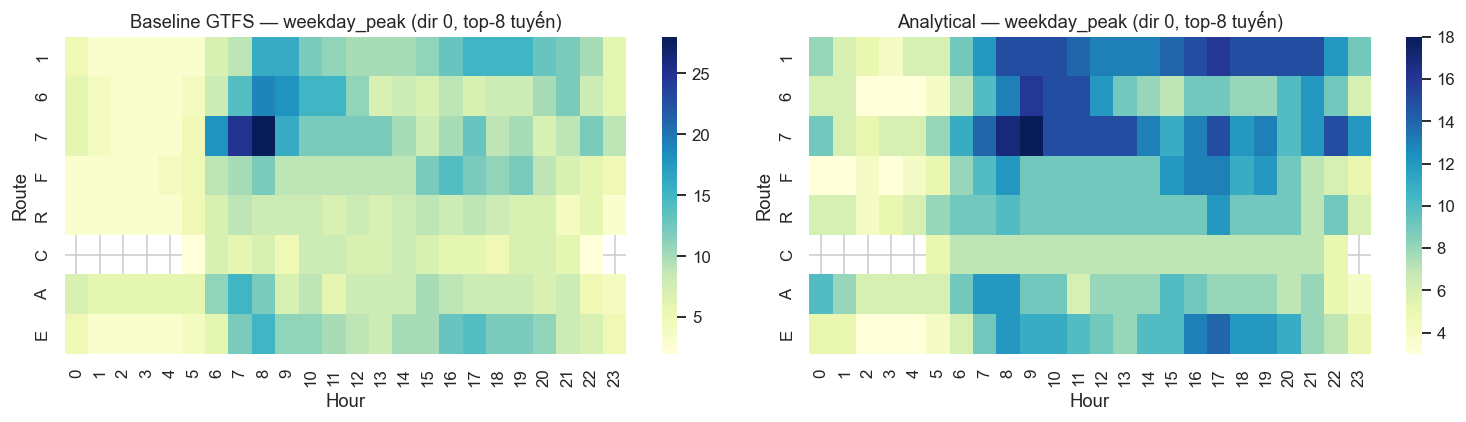

In [24]:
def reshape_trip_matrix(sol: np.ndarray, direction: int, routes: list) -> pd.DataFrame:
    sub = pd.DataFrame({
        "route": slot_route, "dir": slot_dir, "hour": slot_hour, "trips": sol
    })
    sub = sub[sub["dir"] == direction]
    return sub.pivot(index="route", columns="hour", values="trips").reindex(routes)

HEATMAP_ROUTES = [r for r in route_totals.index.astype(str) if r in set(OPT_ROUTES)][:8]
if not HEATMAP_ROUTES:
    HEATMAP_ROUTES = list(OPT_ROUTES)[:8]
scen_to_show = "weekday_peak"
best_label = "Analytical"
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (method, sol) in zip(axes, [
    ("Baseline GTFS", baseline_trips),
    (best_label, opt_results[scen_to_show]),
]):
    m = reshape_trip_matrix(sol, direction=0, routes=HEATMAP_ROUTES)
    sns.heatmap(m, annot=False, fmt=".0f", cmap="YlGnBu", ax=ax)
    ax.set_title(f"{method} — {scen_to_show} (dir 0, top-8 tuyến)")
    ax.set_xlabel("Hour"); ax.set_ylabel("Route")
plt.tight_layout()
plt.savefig(OUT_DIR / f"fig_schedule_{scen_to_show}.png", dpi=120, bbox_inches="tight")
plt.show()


In [25]:
summary_metrics = {
    "run_experiment": "default",
    "demand_model_type": "blend",
    "n_slots": int(N_SLOTS),
    "n_routes": int(len(OPT_ROUTES)),
    "n_hours": int(len(OPT_HOURS)),
    "routes": list(OPT_ROUTES),
    "opt_method": "Analytical",
    "n_headway_fallback": int(n_fallback),
    "scenarios": list(scenario_demand.keys()),
    "lambda_tradeoff_default": float(LAMBDA_TRADEOFF),
    "cost_per_vehicle_hour": float(COST_PER_VEHICLE_HOUR),
    "lambda_opt": float(_lambda_knee_median()),
    "lambda_used": {
        k: (v["median"] if isinstance(v, dict) else float(v))
        for k, v in lambda_used.items()
    },
    "lambda_used_per_route": {str(k): float(v) for k, v in lambda_knee_per_route.items()},
    "lambda_mode": "per_route" if USE_PER_ROUTE_LAMBDA and lambda_knee_per_route else "global",
    "system_fleet_capacity": float(SYSTEM_FLEET_CAPACITY),
    "split_demand_by_direction": bool(SPLIT_DEMAND_BY_DIRECTION),
    "bound_status": {s: srp.bound_status_jsonable(st) for s, st in bound_status.items()},
    "bound_by_hour": bound_by_hour if "bound_by_hour" in dir() else {},
    "lambda_candidates": sorted({float(v) for v in lambda_knee_per_route.values()}),
    "baseline": {s: baseline_metrics[s] for s in scenario_demand},
    "optimized": {s: evaluate_schedule(opt_results[s], scenario_demand[s])
                  for s in scenario_demand},
    "nn_eval": nn_eval_metrics,
    "lambda_knee_per_route": {str(k): float(v) for k, v in lambda_knee_per_route.items()},
    "pareto_per_route_weekday_peak": pareto_per_route.to_dict(orient="records"),
    "pareto_knee_weekday_peak": knee_row,
}

srp.dump_json(OUT_DIR / "baseline_metrics.json", summary_metrics, indent=2)
print("Đã ghi:", OUT_DIR / "baseline_metrics.json")



Đã ghi: outputs\default\baseline_metrics.json


## 9. Export cho UI/API

Gói model + optimizer state → `outputs/default/ui_export/` (API không re-train).

File chính: `demand_model.keras`, `optimizer_state.pkl`, `schedule_{scenario}.json`, `ui_config.json`.


In [26]:
import json
import joblib
import shutil
from datetime import datetime, timezone

UI_DIR = OUT_DIR / "ui_export"
UI_DIR.mkdir(parents=True, exist_ok=True)

# Đảm bảo blend weight đã tune trước khi export
tune_blend_weight_mlp()

# --- C1. Demand model artifacts ---
model.save(UI_DIR / "demand_model.keras")
joblib.dump(scaler, UI_DIR / "scaler.pkl")
if histgbm_model is not None:
    joblib.dump(histgbm_model, UI_DIR / "histgbm_blend.pkl")
if "quantile_models" in globals():
    joblib.dump(quantile_models, UI_DIR / "quantile_gbm_q75.pkl")

# --- C1b. Baseline lookup + inference bundle (API demand prediction) ---
baseline_lookup.reset_index().to_json(
    UI_DIR / "baseline_lookup.json", orient="records", indent=2, force_ascii=False
)
fallback.reset_index().to_json(
    UI_DIR / "fallback_baseline.json", orient="records", indent=2, force_ascii=False
)
srp.dump_json(UI_DIR / "lag_feature_defaults.json", lag_feature_defaults, indent=2)

_feature_med_cols = [c for c in NUM_FEATURES if c in df.columns and c != "log_baseline"]
feature_medians = {
    c: float(pd.to_numeric(df[c], errors="coerce").median()) for c in _feature_med_cols
}
srp.dump_json(UI_DIR / "feature_medians.json", feature_medians, indent=2)

_fb_route = df.groupby(["route_id", "is_weekend"])["demand"].median().rename("fb_route_weekend")
_fb_hour = df.groupby(["hour", "is_weekend"])["demand"].median().rename("fb_hour_weekend")
_fb_global = float(pd.to_numeric(df["demand"], errors="coerce").dropna().median())
if not np.isfinite(_fb_global) or _fb_global <= 0:
    _fb_global = 100.0

demand_inference = {
    "scaler": scaler,
    "histgbm_model": histgbm_model,
    "blend_mlp_weight": float(blend_weight_mlp),
    "resid_clip": tuple(RESID_CLIP),
    "num_features": list(NUM_FEATURES),
    "route_to_idx": {str(k): int(v) for k, v in route_to_idx.items()},
    "baseline_lookup": baseline_lookup,
    "fallback": fallback,
    "lag_feature_defaults": lag_feature_defaults,
    "feature_medians": feature_medians,
    "fb_route_weekend": _fb_route,
    "fb_hour_weekend": _fb_hour,
    "fb_global": _fb_global,
    "use_route_embedding": bool(USE_ROUTE_EMBEDDING),
    "use_lag_features": bool(USE_LAG_FEATURES),
    "lag_feature_cols": list(LAG_FEATURE_COLS),
    "hourly_factor_cols": list(HOURLY_FACTOR_COLS),
}
joblib.dump(demand_inference, UI_DIR / "demand_inference.pkl")

# --- C2. Route & slot metadata ---
route_meta = {
    "opt_routes": [str(r) for r in OPT_ROUTES],
    "ridership_routes": [str(r) for r in RIDERSHIP_ROUTES],
    "missing_ridership_routes": [str(r) for r in MISSING_RIDERSHIP_ROUTES],
    "route_to_idx": {str(k): int(v) for k, v in route_to_idx.items()},
    "route_dir_hours": {
        f"{r}|{d}": [int(h) for h in hs]
        for (r, d), hs in route_dir_hours.items()
    },
    "n_slots": int(N_SLOTS),
    "directions": [int(d) for d in DIRECTIONS],
    "opt_hours": [int(h) for h in OPT_HOURS],
}
srp.dump_json(UI_DIR / "route_meta.json", route_meta, indent=2)

# --- C3. Tunable config snapshot (UI form defaults) ---
ui_config = {
    "demand_model_type": "blend",

    "resid_clip": float(RESID_CLIP[1]),
    "blend_mlp_weight": float(blend_weight_mlp),
    "lambda_opt": float(_lambda_knee_median()),
    "lambda_tradeoff": float(LAMBDA_TRADEOFF),
    "cost_per_vehicle_hour": float(COST_PER_VEHICLE_HOUR),
    "lambda_cost_eval": float(COST_PER_VEHICLE_HOUR),
    "lambda_knee_per_route": {str(k): float(v) for k, v in lambda_knee_per_route.items()},
    "use_per_route_lambda": bool(USE_PER_ROUTE_LAMBDA),
    "system_fleet_capacity": float(SYSTEM_FLEET_CAPACITY),
    "trips_peak_max_factor": float(TRIPS_PEAK_MAX_FACTOR),
    "trips_offpeak_max_factor": float(TRIPS_OFFPEAK_MAX_FACTOR),
    "trips_overnight_max_factor": float(TRIPS_OVERNIGHT_MAX_FACTOR),
    "trips_min_factor": float(TRIPS_MIN_FACTOR),
    "trips_overnight_min_factor": float(TRIPS_OVERNIGHT_MIN_FACTOR),
    "risk_scenarios": list(RISK_SCENARIOS),
    "risk_demand_quantile": float(RISK_DEMAND_QUANTILE),
    "trips_max_delta": int(TRIPS_MAX_DELTA),
    "min_headway_min": float(MIN_HEADWAY_MIN),
    "max_headway_min": float(MAX_HEADWAY_MIN),
    "turnaround_buffer_min": float(TURNAROUND_BUFFER_MIN),
    "max_overflow_pct": float(MAX_OVERFLOW_PCT),
    "smoothness_max_delta": int(SMOOTHNESS_MAX_DELTA),
    "target_max_bind_fraction": float(TARGET_MAX_BIND_FRACTION),
    "target_peak_bind_fraction": float(TARGET_PEAK_BIND_FRACTION),
    "rainy_peak_trips_min_factor": float(RAINY_PEAK_TRIPS_MIN_FACTOR),
    "overnight_max_headway_min": float(OVERNIGHT_MAX_HEADWAY_MIN),
    "rainy_offpeak_max_factor": float(RAINY_OFFPEAK_MAX_FACTOR),
    "use_demand_spillover": False,
    "scenarios": list(SCENARIOS),
    "rainy_hour_boost": {str(k): float(v) for k, v in RAINY_HOUR_BOOST.items()},
    "num_features": list(NUM_FEATURES),
    "lag_feature_cols": list(LAG_FEATURE_COLS),
    "nn_hidden": list(NN_HIDDEN),
    "capacity_per_trip": int(CAPACITY_PER_TRIP),
    "use_route_embedding": bool(USE_ROUTE_EMBEDDING),
    "split_demand_by_direction": bool(SPLIT_DEMAND_BY_DIRECTION),
    "lambda_auto_calibrate": bool(LAMBDA_AUTO_CALIBRATE),
}
srp.dump_json(UI_DIR / "ui_config.json", ui_config, indent=2)

# --- C4. Optimizer replay state ---
joblib.dump(
    {
        "baseline_trips": baseline_trips,
        "TRIPS_MIN": TRIPS_MIN,
        "TRIPS_MAX": TRIPS_MAX,
        "slot_route": slot_route,
        "slot_dir": slot_dir,
        "slot_hour": slot_hour,
        "direction_share": direction_share,
        "baseline_lookup": baseline_lookup,
        "fallback": fallback,
        "lag_feature_defaults": lag_feature_defaults,
        "fb_route_weekend": _fb_route,
        "fb_hour_weekend": _fb_hour,
        "fb_global": _fb_global,
        "service_windows": service_windows,
        "cycle_times": cycle_times,
        "fleet_by_route_dir": fleet_by_route_dir,
        "system_fleet_capacity": float(SYSTEM_FLEET_CAPACITY),
        "lambda_knee_per_route": {str(k): float(v) for k, v in lambda_knee_per_route.items()},
        "scenario_demand": {s: scenario_demand[s] for s in SCENARIOS},
    },
    UI_DIR / "optimizer_state.pkl",
)

# --- C5. Pareto per-route ---
pareto_per_route.to_json(UI_DIR / "pareto_per_route.json", orient="records", indent=2, force_ascii=False)
srp.dump_json(UI_DIR / "pareto_knee.json", knee_row, indent=2)

# --- C6. Optimized schedules per scenario ---
for scen in SCENARIOS:
    tmin, tmax = trips_bounds_for_scenario(scen)
    sched = pd.DataFrame({
        "route": slot_route,
        "direction": slot_dir,
        "hour": slot_hour,
        "baseline_trips": baseline_trips,
        "opt_trips": opt_results[scen],
        "demand_pred": scenario_demand[scen],
        "trips_min": tmin,
        "trips_max": tmax,
        "at_max": (opt_results[scen] >= tmax).astype(int),
    })
    sched.to_json(UI_DIR / f"schedule_{scen}.json", orient="records", indent=2, force_ascii=False)

# --- C7. Spillover benefit by route ---


# --- C9. Run metrics snapshot + copy full baseline_metrics ---
run_metrics = {
    "exported_at": datetime.now(timezone.utc).isoformat(),
    "out_dir": str(OUT_DIR),
    "lambda_used": {
        k: (v["median"] if isinstance(v, dict) else float(v))
        for k, v in lambda_used.items()
    },
    "lambda_used_detail": lambda_used,
    "system_fleet_capacity": float(SYSTEM_FLEET_CAPACITY),
    "bound_status": {s: srp.bound_status_jsonable(st) for s, st in bound_status.items()},
    "bound_by_hour": bound_by_hour,
    "optimized": summary_metrics["optimized"],
    "baseline": summary_metrics["baseline"],
    "pareto_knee": knee_row,
}
srp.dump_json(UI_DIR / "run_metrics.json", run_metrics, indent=2)

_src_bm = OUT_DIR / "baseline_metrics.json"
if _src_bm.exists():
    shutil.copy(_src_bm, UI_DIR / "baseline_metrics.json")

manifest = {
    "exported_at": run_metrics["exported_at"],
    "ui_dir": str(UI_DIR),
    "files": sorted(p.name for p in UI_DIR.iterdir() if p.is_file()),
}
srp.dump_json(UI_DIR / "manifest.json", manifest, indent=2)

print(f"✓ UI export → {UI_DIR.resolve()}")
print(f"  {len(manifest['files'])} files:", ", ".join(manifest["files"]))



✓ UI export → D:\tranport-public\notebooks\outputs\default\ui_export
  19 files: baseline_lookup.json, baseline_metrics.json, demand_inference.pkl, demand_model.keras, fallback_baseline.json, feature_medians.json, histgbm_blend.pkl, lag_feature_defaults.json, optimizer_state.pkl, pareto_knee.json, pareto_per_route.json, quantile_gbm_q75.pkl, route_meta.json, run_metrics.json, scaler.pkl, schedule_rainy_day.json, schedule_weekday_peak.json, schedule_weekend.json, ui_config.json


## 10. Lịch ga & mô phỏng trễ (demo)

Lịch chi tiết đến ga, fleet sweep-line, what-if delay propagation. Không đổi optimizer §1–§9.


Lịch chi tiết route 1: 39122 dòng (trip × ga), 24 trips

Fleet — trung bình underestimate của lower bound: -5.9%
route_id  direction_id  fleet_lower_bound  fleet_continuous  pct_underestimate
      FS             1               2.30               3.0              23.33
       H             1               2.33               3.0              22.23
       H             0               2.33               3.0              22.23
      FS             0               2.40               3.0              20.00
       G             0              10.53              11.0               4.24

[Demo] Trip 13 trễ 5 phút tại stop_sequence=18:
  Trip bị ảnh hưởng: 1 | Tổng hold: 357.5 phút | Max hold 1 trip: 5.0 phút


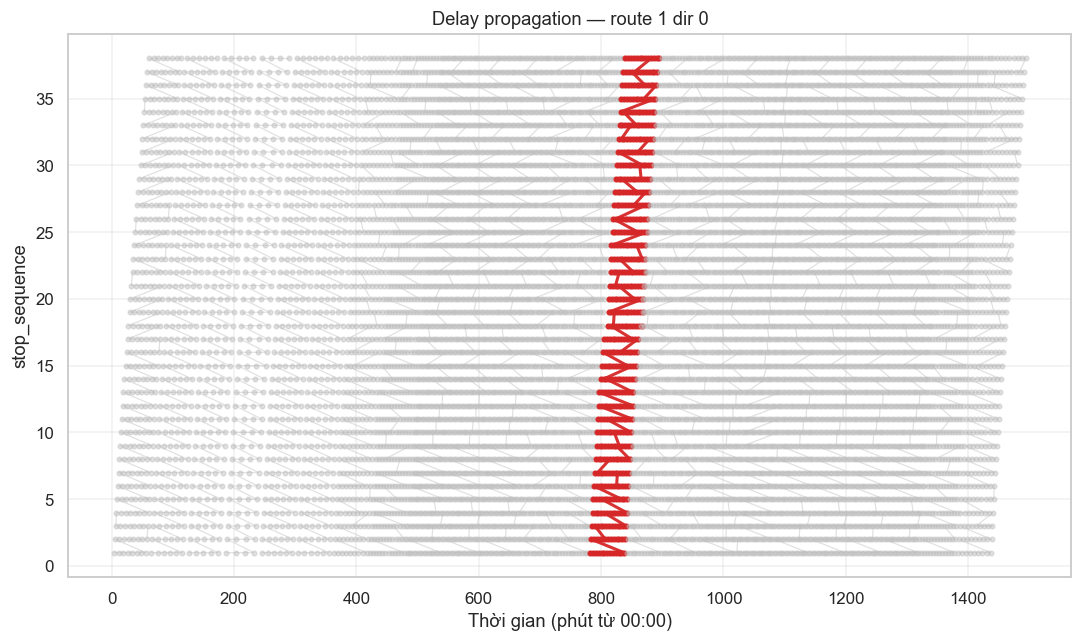

Đã lưu §10: outputs\default\station_schedule_1.csv | outputs\default\fleet_estimate_comparison.csv | outputs\default\delay_simulation_1.csv


In [27]:
import importlib
importlib.reload(srp)

# --- 11a. Build lịch chi tiết đến ga cho 1 route demo ---
demo_route = OPT_ROUTES[0]
offset_templates = srp.load_gtfs_stop_offset_templates(SCHEDULE_DIR, service_id=HEADWAY_SERVICE)

demo_station_schedule = srp.build_station_schedule_for_route(
    opt_results["weekday_peak"],
    slot_route, slot_dir, slot_hour,
    SCHEDULE_DIR, demo_route, offset_templates=offset_templates,
)
demo_station_schedule = srp.assign_trip_ids(demo_station_schedule)
print(
    f"Lịch chi tiết route {demo_route}: {len(demo_station_schedule)} dòng "
    f"(trip × ga), {demo_station_schedule['trip_id'].nunique()} trips"
)
demo_station_schedule.to_csv(OUT_DIR / f"station_schedule_{demo_route}.csv", index=False)

# --- 11b. Fleet chính xác cho toàn mạng ---
fleet_comparison = srp.compare_fleet_estimates(
    baseline_trips, slot_route, slot_dir, slot_hour, cycle_times
)
fleet_comparison.to_csv(OUT_DIR / "fleet_estimate_comparison.csv", index=False)
print(
    f"\nFleet — trung bình underestimate của lower bound: "
    f"{fleet_comparison['pct_underestimate'].mean():.1f}%"
)
print(
    fleet_comparison.sort_values("pct_underestimate", ascending=False)
    .head(5).round(2).to_string(index=False)
)

# --- 11c. Mô phỏng trễ (what-if demo) trên lịch route đã build ở 11a ---
_demo_dir = int(demo_station_schedule["direction"].iloc[0])
_demo_trip = int(demo_station_schedule["trip_id"].median())
_demo_stop_seq = int(
    demo_station_schedule.loc[
        demo_station_schedule["trip_id"] == _demo_trip, "stop_sequence"
    ].median()
)

adjusted = srp.simulate_delay_propagation(
    demo_station_schedule,
    route_id=demo_route,
    direction_id=_demo_dir,
    delayed_trip_id=_demo_trip,
    delay_min=5.0,
    delay_at_stop_sequence=_demo_stop_seq,
    min_headway_ratio=0.6,
    max_propagation_trips=3,
    dwell_recovery_min=0.5,
)
impact = srp.summarize_delay_impact(adjusted)
print(f"\n[Demo] Trip {_demo_trip} trễ 5 phút tại stop_sequence={_demo_stop_seq}:")
print(
    f"  Trip bị ảnh hưởng: {impact['n_trips_affected']} | "
    f"Tổng hold: {impact['total_hold_min']:.1f} phút | "
    f"Max hold 1 trip: {impact['max_hold_min']:.1f} phút"
)

srp.plot_delay_propagation(
    adjusted, route_id=demo_route, direction_id=_demo_dir,
    title=f"Delay propagation — route {demo_route} dir {_demo_dir}",
    save_path=OUT_DIR / f"fig_delay_propagation_{demo_route}.png",
)
plt.show()
adjusted.to_csv(OUT_DIR / f"delay_simulation_{demo_route}.csv", index=False)
print(
    "Đã lưu §10:", OUT_DIR / f"station_schedule_{demo_route}.csv", "|",
    OUT_DIR / "fleet_estimate_comparison.csv", "|",
    OUT_DIR / f"delay_simulation_{demo_route}.csv",
)

## 11. Kết luận

- **Demand:** blend MLP + HistGBM, R² ≈ 0.98; demand trực tiếp theo route (không spillover).
- **Wait:** queue propagation giữa các giờ; không dùng hệ số overflow 1.5×.
- **Pareto:** f1 = passenger-min wait vs f2 = vehicle-hours; knee λ per route.
- **Triển khai:** chạy §9 → `outputs/default/ui_export/`.

